# 🌊 DAQathon Session 1: QC with Random Forests, CNNs, and k-means

This notebook is designed for a mixed audience. Some people will be very comfortable with machine learning already, and others may be seeing terms like *Random Forest*, *k-means*, or *convolutional neural network* for the first time.

The goal is to make the workflow feel approachable while still using a real ONC quality-control problem:

- start from raw CTD data and ONC QC flags,
- build one clear supervised baseline,
- build one clear unsupervised example,
- and leave with a better sense of how to improve the pipeline later.


## 🧭 How To Use This Notebook

This notebook is meant to feel like a first clean pass through the workflow:

- understand the dataset and QC flags,
- build one reasonable tabular baseline with a Random Forest,
- build one reasonable sequential baseline with a CNN,
- then ask what we might improve next.

A few suggestions for live teaching:

- read the markdown cells first, then run the code cells underneath them,
- use `DATA_FRACTION` in the config cell to switch between a quick demo and a longer run,
- treat the default model settings as **baseline choices**, not as final answers.

Optional background reading:

- [Random Forests in scikit-learn](https://scikit-learn.org/stable/modules/ensemble.html#forest)
- [k-means clustering in scikit-learn](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [Neural networks in PyTorch](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial)
- [ONC Quality Flags reference](https://wiki.oceannetworks.ca/display/DP/Quality+Flags)


## ⚙️ Configuration

Change values in the next cell if you want to trade speed for fidelity, switch between multiclass and binary classification, or enable the GPU CNN appendix.

On FIR, if `$SLURM_TMPDIR` is available, this notebook first stages the shared raw CSV directory and the prepared parquet cache into node-local job storage. It writes all generated outputs into a runtime directory chosen in this order:

1. `$SLURM_TMPDIR`
2. `$SCRATCH`
3. repo-local `tmp/session1_outputs`


In [11]:
#Install the necessary kernel.  After this runs, save, and close this notebook, then re-open it
!jupyter kernelspec install --user /project/def-kmoran/shared/daqathon/kernels/daqathon-ml

1488.49s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


[InstallKernelSpec] Removing existing kernelspec in /home/slonimer/.local/share/jupyter/kernels/daqathon-ml
[InstallKernelSpec] Installed kernelspec daqathon-ml in /home/slonimer/.local/share/jupyter/kernels/daqathon-ml


In [2]:
from pathlib import Path

def first_existing_path(candidates: list[Path]) -> Path | None:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

def first_existing_csv_dir(candidates: list[Path]) -> Path | None:
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir() and any(candidate.glob("*.csv")):
            return candidate
    return None

# Find the repo root for the cloned participant repo.
NOTEBOOK_ROOT = Path.cwd()
for candidate_root in [NOTEBOOK_ROOT, *NOTEBOOK_ROOT.parents]:
    if (candidate_root / "notebooks").exists() and (candidate_root / "scripts").exists():
        NOTEBOOK_ROOT = candidate_root
        break

# Detect the shared FIR project space that holds the long-lived data,
# shared environment, and kernel.
shared_root_candidates = [
    Path("/project/def-kmoran/shared/daqathon"),
    Path("/project/6062898/shared/daqathon"),
    Path.home() / "projects" / "def-kmoran" / "shared" / "daqathon",
]
SHARED_DAQATHON_ROOT = first_existing_path(shared_root_candidates)


#Specify folder with RAW CSV data here:
LOCAL_RAW_DATA_DIR = NOTEBOOK_ROOT / "data" / "raw" / "Fluorometer" / "SoGCentral_test"
#LOCAL_RAW_DATA_DIR = NOTEBOOK_ROOT / "data" / "raw" / "SoGEast_CTD_202503_202603"
LOCAL_CACHE_DIR = NOTEBOOK_ROOT / "data" / "cache" / "session1"
SHARED_RAW_DATA_DIR = (
    first_existing_csv_dir(
        [
            SHARED_DAQATHON_ROOT / "data" / "raw" / "Fluorometer" / "SoGCentral_test",
            #SHARED_DAQATHON_ROOT / "data" / "raw" / "SoGEast_CTD_202503_202603",
            SHARED_DAQATHON_ROOT / "data" / "raw",
        ]
    )
    if SHARED_DAQATHON_ROOT
    else None
)
SHARED_CACHE_DIR = (
    first_existing_path([SHARED_DAQATHON_ROOT / "data" / "cache" / "session1"])
    if SHARED_DAQATHON_ROOT
    else None
)

default_raw_candidates = [
    SHARED_RAW_DATA_DIR,
    LOCAL_RAW_DATA_DIR,
    NOTEBOOK_ROOT / "data" / "raw",
]
default_cache_candidates = [
    LOCAL_CACHE_DIR,
    SHARED_CACHE_DIR,
]

DEFAULT_RAW_DATA_DIR = first_existing_csv_dir([candidate for candidate in default_raw_candidates if candidate is not None]) or first_existing_path([candidate for candidate in default_raw_candidates if candidate is not None])
DEFAULT_READ_CACHE_DIR = first_existing_path([candidate for candidate in default_cache_candidates if candidate is not None])

# These defaults are detected automatically, but they are still plain values
# you can edit directly in the notebook if you need to point somewhere else.
READ_RAW_DATA_DIR = str(DEFAULT_RAW_DATA_DIR) if DEFAULT_RAW_DATA_DIR is not None else str(LOCAL_RAW_DATA_DIR)
READ_CACHE_DIR = str(DEFAULT_READ_CACHE_DIR) if DEFAULT_READ_CACHE_DIR is not None else str(LOCAL_CACHE_DIR)




In [ ]:
example = 'FluorometerExample'

if example == 'ConductivityTestExample':

    #Select the column to use as the "class" for training
    TARGET_FLAG = "Conductivity QC Flag"
    TASK_MODE = "multiclass"
    EXAMPLE_DEVICE = 'conductivity'
    CACHE_BUNDLE_NAME = "conductivity_scalar_session1"
    measurement_column_str = 'Conductivity (S/m)' 
    secondary_column_str = 'Temperature (C)' 

    # Keep the feature list in one place so later cells reuse the same columns.
    MEASUREMENT_COLUMNS = [
        "Conductivity (S/m)",
        "Density (kg/m3)",
        "Depth (m)",
        "Practical Salinity (psu)",
        "Pressure (decibar)",
        "Sigma-t (kg/m3)",
        "Sigma-theta (0 dbar) (kg/m3)",
        "Sound Speed (m/s)",
        "Temperature (C)",
    ]

    # Read only the parquet columns we actually use in this notebook.
    OPTIONAL_QC_COLUMNS = [TARGET_FLAG, "Temperature QC Flag"]
    ROW_USE_COLUMNS = list(dict.fromkeys(["Time UTC", "source_file", *OPTIONAL_QC_COLUMNS, *MEASUREMENT_COLUMNS]))
    WINDOW_FEATURE_COLUMNS = [
        f"{column}_{stat}"
        for column in MEASUREMENT_COLUMNS
        for stat in ("mean", "std")
    ]
    WINDOW_USE_COLUMNS = [
        "window_start",
        "window_end",
        "source_file",
        "issue_rate",
        *WINDOW_FEATURE_COLUMNS,
    ]

    # One easy workshop knob: set this to something like 0.1 for a quick run or 1.0 for the largest local run.
    DATA_FRACTION = 1.0
    if not 0 < DATA_FRACTION <= 1:
        raise ValueError("DATA_FRACTION must be in the interval (0, 1].")

    # These base values are used later in small local config cells.
    BASE_ROWS_PER_FILE = 45000
    BASE_ISSUE_ROWS_PER_FILE = 12000
    BASE_MODEL_ROW_LIMIT = 1_000_000
    BASE_WINDOW_POINT_LIMIT = 1.0
    BASE_FLAG_EXAMPLE_POINTS_PER_PANEL = 30000


elif example == 'FluorometerExample':

    TARGET_FLAG = "Turbidity QC Flag" #Note: Chlorophyll QC flag is added as an optional QC column below
    #TARGET_FLAG = "Conductivity QC Flag"
    TASK_MODE = "multiclass"
    EXAMPLE_DEVICE = 'fluorometer'
    CACHE_BUNDLE_NAME = "fluorometer_scalar_session1"
    measurement_column_str = 'Turbidity (NTU)' 
    secondary_column_str = 'Temperature (C)' 

    # Keep the feature list in one place so later cells reuse the same columns.
    MEASUREMENT_COLUMNS = [
        "Chlorophyll (ug/l)",
        "Turbidity (NTU)",
        "Conductivity (S/m)",
        "Density (kg/m3)",
        "Depth (m)",
        "Practical Salinity (psu)",
        "Pressure (decibar)",
        "Sigma-t (kg/m3)",
        "Sigma-theta (0 dbar) (kg/m3)",
        "Sound Speed (m/s)",
        "Temperature (C)",
        "Oxygen Concentration Corrected (ml/l)",
        "Oxygen Concentration Uncorrected (ml/l)",
    ]

    # Read only the parquet columns we actually use in this notebook.
    OPTIONAL_QC_COLUMNS = [TARGET_FLAG, "Chlorophyll QC Flag"]
    ROW_USE_COLUMNS = list(dict.fromkeys(["Time UTC", "source_file", *OPTIONAL_QC_COLUMNS, *MEASUREMENT_COLUMNS]))
    WINDOW_FEATURE_COLUMNS = [
        f"{column}_{stat}"
        for column in MEASUREMENT_COLUMNS
        for stat in ("mean", "std")
    ]
    WINDOW_USE_COLUMNS = [
        "window_start",
        "window_end",
        "source_file",
        "issue_rate",
        *WINDOW_FEATURE_COLUMNS,
    ]

    # One easy workshop knob: set this to something like 0.1 for a quick run or 1.0 for the largest local run.
    DATA_FRACTION = 1.0
    if not 0 < DATA_FRACTION <= 1:
        raise ValueError("DATA_FRACTION must be in the interval (0, 1].")

    # These base values are used later in small local config cells.
    BASE_ROWS_PER_FILE = 45000
    BASE_ISSUE_ROWS_PER_FILE = 12000
    BASE_MODEL_ROW_LIMIT = 1_000_000
    BASE_WINDOW_POINT_LIMIT = 1.0
    BASE_FLAG_EXAMPLE_POINTS_PER_PANEL = 30000


# Global row/window selection policy.
PART_SELECTION_MODE = "spread"
ROW_FILE_LIMIT = None

# Time-based split fractions.
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

# Toggle the GPU appendix.
RUN_CNN_APPENDIX = True
SEED = 21

print(
    {
        "TASK_MODE": TASK_MODE,
        "TARGET_FLAG": TARGET_FLAG,
        "CACHE_BUNDLE_NAME": CACHE_BUNDLE_NAME,
        "DATA_FRACTION": DATA_FRACTION,
        "RUN_CNN_APPENDIX": RUN_CNN_APPENDIX,
        "SHARED_DAQATHON_ROOT": str(SHARED_DAQATHON_ROOT) if SHARED_DAQATHON_ROOT else None,
        "READ_RAW_DATA_DIR": READ_RAW_DATA_DIR,
        "READ_CACHE_DIR": READ_CACHE_DIR,
    }
)

{'TASK_MODE': 'multiclass', 'TARGET_FLAG': 'Turbidity QC Flag', 'CACHE_BUNDLE_NAME': 'fluorometer_scalar_session1', 'DATA_FRACTION': 1.0, 'RUN_CNN_APPENDIX': True, 'SHARED_DAQATHON_ROOT': '/project/def-kmoran/shared/daqathon', 'READ_RAW_DATA_DIR': '/project/def-kmoran/shared/daqathon/data/raw/Fluorometer/SoGCentral_test', 'READ_CACHE_DIR': '/project/def-kmoran/shared/daqathon/data/cache/session1'}


In [4]:
from __future__ import annotations

import copy
import importlib
import json
import os
import pickle
import subprocess
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

import scripts.prepare_scalar_session1_data as prepare_scalar_session1_data
import scripts.session1_modeling as session1_modeling

importlib.invalidate_caches()
prepare_scalar_session1_data = importlib.reload(prepare_scalar_session1_data)
session1_modeling = importlib.reload(session1_modeling)


def choose_cache_paths(cache_roots: list[str | Path | None], cache_stem: str):
    fallback_root: Path | None = None
    for cache_root in cache_roots:
        if cache_root is None:
            continue
        root_path = Path(cache_root).expanduser()
        if fallback_root is None:
            fallback_root = root_path
        candidate = session1_modeling.resolve_cache_bundle_paths(root_path, cache_stem=cache_stem)
        if candidate.metadata_path.exists():
            return candidate
    if fallback_root is None:
        raise ValueError("At least one cache root is required")
    return session1_modeling.build_cache_bundle_paths(fallback_root, cache_stem)


SLURM_TMPDIR = os.environ.get("SLURM_TMPDIR")
SCRATCH = os.environ.get("SCRATCH")
RUNTIME_OUTPUT_ROOT = (
    Path(SLURM_TMPDIR) / "daqathon" / "session1_outputs"
    if SLURM_TMPDIR
    else (Path(SCRATCH) / "daqathon" / "session1_outputs" if SCRATCH else NOTEBOOK_ROOT / "tmp" / "session1_outputs")
)
RUNTIME_RAW_DATA_DIR = RUNTIME_OUTPUT_ROOT / "data" / "raw" / Path(READ_RAW_DATA_DIR).name
RUNTIME_CACHE_DIR = RUNTIME_OUTPUT_ROOT / "cache" / "session1"
ARTIFACT_DIR = RUNTIME_OUTPUT_ROOT / "artifacts"
MODEL_OUTPUT_DIR = RUNTIME_OUTPUT_ROOT / "models"
PLOT_OUTPUT_DIR = RUNTIME_OUTPUT_ROOT / "plots"
REPORT_OUTPUT_DIR = RUNTIME_OUTPUT_ROOT / "reports"

for output_dir in [RUNTIME_OUTPUT_ROOT, ARTIFACT_DIR, MODEL_OUTPUT_DIR, PLOT_OUTPUT_DIR, REPORT_OUTPUT_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

USE_RUNTIME_RAW_DATA_FOR_READS = bool(SLURM_TMPDIR)
USE_RUNTIME_CACHE_FOR_READS = bool(SLURM_TMPDIR)
RAW_DATA_DIR = str(RUNTIME_RAW_DATA_DIR if USE_RUNTIME_RAW_DATA_FOR_READS else Path(READ_RAW_DATA_DIR))
CACHE_DIR = str(RUNTIME_CACHE_DIR if USE_RUNTIME_CACHE_FOR_READS else Path(READ_CACHE_DIR))
cache_paths = session1_modeling.build_cache_bundle_paths(CACHE_DIR, CACHE_BUNDLE_NAME)
ROW_CACHE_DIR = str(cache_paths.row_level_dir)
WINDOW_CACHE_PATH = str(cache_paths.window_cache_path)
METADATA_PATH = str(cache_paths.metadata_path)

RF_MODEL_PATH = MODEL_OUTPUT_DIR / "best_random_forest.pkl"
CNN_MODEL_PATH = MODEL_OUTPUT_DIR / "best_cnn_checkpoint.pt"
TRANSFORMER_MODEL_PATH = MODEL_OUTPUT_DIR / "best_transformer_checkpoint.pt"

add_temporal_context_features = session1_modeling.add_temporal_context_features
apply_target_strategy = session1_modeling.apply_target_strategy
build_cache_bundle_paths = session1_modeling.build_cache_bundle_paths
build_labeled_intervals = session1_modeling.build_labeled_intervals
build_model_frame = session1_modeling.build_model_frame
build_sequence_label_interval_data = session1_modeling.build_sequence_label_interval_data
build_window_classification_interval_data = session1_modeling.build_window_classification_interval_data
compute_interval_classification_metrics = session1_modeling.compute_interval_classification_metrics
DEFAULT_FLAG_PALETTE = session1_modeling.DEFAULT_FLAG_PALETTE
evaluate_classifier = session1_modeling.evaluate_classifier
fit_extra_trees = session1_modeling.fit_extra_trees
fit_random_forest = session1_modeling.fit_random_forest
infer_interval_origin = session1_modeling.infer_interval_origin
load_rows_for_time_range = session1_modeling.load_rows_for_time_range
merge_adjacent_intervals = session1_modeling.merge_adjacent_intervals
plot_cluster_window_examples = session1_modeling.plot_cluster_window_examples
plot_flag_examples = session1_modeling.plot_flag_examples
plot_time_series_with_bands = session1_modeling.plot_time_series_with_bands
predict_cnn_window_model = session1_modeling.predict_cnn_window_model
predict_sequence_label_cnn = session1_modeling.predict_sequence_label_cnn
predict_transformer_window_model = session1_modeling.predict_transformer_window_model
resolve_cache_bundle_paths = session1_modeling.resolve_cache_bundle_paths
resolve_runtime_output_root = session1_modeling.resolve_runtime_output_root
select_time_range = session1_modeling.select_time_range
run_cnn_search = session1_modeling.run_cnn_search
run_rf_search = session1_modeling.run_rf_search
stage_directory_into_runtime = session1_modeling.stage_directory_into_runtime
stage_cache_into_runtime = session1_modeling.stage_cache_into_runtime

DEFAULT_KEEP_COLUMNS = prepare_scalar_session1_data.DEFAULT_KEEP_COLUMNS
locate_header = prepare_scalar_session1_data.locate_header
read_scalar_csv = prepare_scalar_session1_data.read_scalar_csv
KEEP_COLUMNS = DEFAULT_KEEP_COLUMNS
session1_modeling.MEASUREMENT_COLUMNS = MEASUREMENT_COLUMNS.copy()

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
np.random.seed(SEED)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(
    {
        "TASK_MODE": TASK_MODE,
        "TARGET_FLAG": TARGET_FLAG,
        "CACHE_BUNDLE_NAME": CACHE_BUNDLE_NAME,
        "DATA_FRACTION": DATA_FRACTION,
        "RUN_CNN_APPENDIX": RUN_CNN_APPENDIX,
        "SHARED_DAQATHON_ROOT": str(SHARED_DAQATHON_ROOT) if SHARED_DAQATHON_ROOT else None,
        "READ_RAW_DATA_DIR": READ_RAW_DATA_DIR,
        "READ_CACHE_DIR": READ_CACHE_DIR,
        "USE_RUNTIME_RAW_DATA_FOR_READS": USE_RUNTIME_RAW_DATA_FOR_READS,
        "USE_RUNTIME_CACHE_FOR_READS": USE_RUNTIME_CACHE_FOR_READS,
        "RUNTIME_OUTPUT_ROOT": str(RUNTIME_OUTPUT_ROOT),
        "RUNTIME_RAW_DATA_DIR": str(RUNTIME_RAW_DATA_DIR),
        "ROW_CACHE_DIR": ROW_CACHE_DIR,
        "WINDOW_CACHE_PATH": WINDOW_CACHE_PATH,
    }
)

{'TASK_MODE': 'multiclass', 'TARGET_FLAG': 'Turbidity QC Flag', 'CACHE_BUNDLE_NAME': 'fluorometer_scalar_session1', 'DATA_FRACTION': 1.0, 'RUN_CNN_APPENDIX': True, 'SHARED_DAQATHON_ROOT': '/project/def-kmoran/shared/daqathon', 'READ_RAW_DATA_DIR': '/project/def-kmoran/shared/daqathon/data/raw/Fluorometer/SoGCentral_test', 'READ_CACHE_DIR': '/project/def-kmoran/shared/daqathon/data/cache/session1', 'USE_RUNTIME_RAW_DATA_FOR_READS': True, 'USE_RUNTIME_CACHE_FOR_READS': True, 'RUNTIME_OUTPUT_ROOT': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs', 'RUNTIME_RAW_DATA_DIR': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/data/raw/SoGCentral_test', 'ROW_CACHE_DIR': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/cache/session1/fluorometer_scalar_session1_row_level', 'WINDOW_CACHE_PATH': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/cache/session1/fluorometer_scalar_session1_windowed_features.parquet'}


In [5]:
# Helper: take an evenly spaced subset without scrambling time order.
def evenly_spaced_take(frame: pd.DataFrame, limit: int | None) -> pd.DataFrame:
    if limit is None or len(frame) <= limit:
        return frame.reset_index(drop=True)
    indices = np.linspace(0, len(frame) - 1, num=limit, dtype=int)
    return frame.iloc[indices].reset_index(drop=True)


# Helper: choose parquet parts spread across the whole year instead of just the first few files.
def select_part_paths(part_paths: list[Path], limit: int | None, mode: str) -> list[Path]:
    if limit is None or limit >= len(part_paths):
        return part_paths
    if mode == "first":
        return part_paths[:limit]
    if mode == "spread":
        indices = np.linspace(0, len(part_paths) - 1, num=limit, dtype=int)
        selected = []
        seen = set()
        for index in indices:
            candidate = part_paths[int(index)]
            if candidate not in seen:
                selected.append(candidate)
                seen.add(candidate)
        return selected
    raise ValueError(f"Unsupported PART_SELECTION_MODE: {mode}")


# Helper: sample each parquet part and deliberately keep extra rows where the QC flag is not 1.
def load_row_level_sample(
    part_paths: list[Path],
    rows_per_file: int | None,
    issue_rows_per_file: int,
    target_flag: str,
    columns: list[str] | None = None,
) -> pd.DataFrame:
    row_frames = []
    for path in part_paths:
        frame = pd.read_parquet(path, columns=columns).sort_values("Time UTC").reset_index(drop=True)
        frame["Time UTC"] = pd.to_datetime(frame["Time UTC"], utc=True)

        if rows_per_file is None:
            sampled_frame = frame
        else:
            base_limit = max(rows_per_file - issue_rows_per_file, 0)
            sampled_frame = evenly_spaced_take(frame, base_limit)

            if issue_rows_per_file > 0 and target_flag in frame.columns:
                issue_frame = frame[frame[target_flag].fillna(1).astype(int) != 1].reset_index(drop=True)
                issue_sample = evenly_spaced_take(issue_frame, issue_rows_per_file)
                sampled_frame = pd.concat([sampled_frame, issue_sample], ignore_index=True)
                sampled_frame = (
                    sampled_frame.drop_duplicates(subset=["Time UTC"])
                    .sort_values("Time UTC")
                    .reset_index(drop=True)
                )
                sampled_frame = evenly_spaced_take(sampled_frame, rows_per_file)

        row_frames.append(sampled_frame)

    return pd.concat(row_frames, ignore_index=True).sort_values("Time UTC").reset_index(drop=True)


# Helper: contiguous splits mimic a real forecasting-style workflow better than random shuffling.
def contiguous_split(
    frame: pd.DataFrame,
    train_fraction: float,
    validation_fraction: float,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_end = int(len(frame) * train_fraction)
    valid_end = int(len(frame) * (train_fraction + validation_fraction))
    train_frame = frame.iloc[:train_end].copy()
    valid_frame = frame.iloc[train_end:valid_end].copy()
    test_frame = frame.iloc[valid_end:].copy()
    return train_frame, valid_frame, test_frame


# Helper: reduce row-level labels to one window-level label for the CNN.
def reduce_window_target(values: np.ndarray, mode: str, severity_order: tuple[int, ...] = (1, 3, 4, 9)) -> int:
    severity_rank = {label: index for index, label in enumerate(severity_order)}
    labels = [int(value) for value in values if pd.notna(value)]
    if not labels:
        return severity_order[0]
    if mode == "worst":
        return max(labels, key=lambda label: severity_rank.get(label, -1))
    counts = pd.Series(labels).value_counts()
    tied_labels = counts[counts == counts.max()].index.tolist()
    return max(tied_labels, key=lambda label: severity_rank.get(int(label), -1))


def report_average(task_mode: str) -> str:
    return "binary" if task_mode == "binary" else "macro"


## 🚀 FIR Input Staging

On FIR, the shared project space is the long-lived home for the workshop data. When `$SLURM_TMPDIR` is available, this notebook first copies the shared raw CSV directory and the prepared parquet cache into node-local storage, because that local job storage is much faster for interactive notebook work.

That means:

- the shared project space stays as the canonical source,
- the notebook reads from a fast local working copy during the run,
- and all generated files stay in your job-local runtime area instead of polluting the shared project tree.

The next code cell shows a progress bar while those copies are happening.


In [6]:
# On FIR, stage shared inputs into node-local storage before we start reading them.
read_raw_data_dir = Path(READ_RAW_DATA_DIR)
runtime_raw_data_dir = Path(RUNTIME_RAW_DATA_DIR)
read_cache_dir = Path(READ_CACHE_DIR)
runtime_cache_dir = Path(RUNTIME_CACHE_DIR)

raw_stage_result = {"staged": False, "reason": "raw-data staging is disabled because SLURM_TMPDIR is not available"}
cache_stage_result = {"staged": False, "reason": "cache staging is disabled because SLURM_TMPDIR is not available"}
if USE_RUNTIME_RAW_DATA_FOR_READS:
    raw_stage_result = stage_directory_into_runtime(
        source_dir=read_raw_data_dir,
        runtime_dir=runtime_raw_data_dir,
        force=False,
        show_progress=True,
        progress_label=f"Staging raw {EXAMPLE_DEVICE} CSV files to SLURM_TMPDIR",
    )
if USE_RUNTIME_CACHE_FOR_READS:
    cache_stage_result = stage_cache_into_runtime(
        persistent_cache_dir=read_cache_dir,
        runtime_cache_dir=runtime_cache_dir,
        force=False,
        show_progress=True,
        progress_label="Staging parquet cache to SLURM_TMPDIR",
    )

active_raw_data_dir = runtime_raw_data_dir if runtime_raw_data_dir.exists() and any(runtime_raw_data_dir.glob("*.csv")) else read_raw_data_dir
active_cache_dir = runtime_cache_dir if (runtime_cache_dir / f"{EXAMPLE_DEVICE}_session1_metadata.json").exists() else read_cache_dir
RAW_DATA_DIR = str(active_raw_data_dir)
CACHE_DIR = str(active_cache_dir)
ROW_CACHE_DIR = str(active_cache_dir / f"{EXAMPLE_DEVICE}_session1_row_level")
WINDOW_CACHE_PATH = str(active_cache_dir / f"{EXAMPLE_DEVICE}_session1_windowed_features.parquet")
METADATA_PATH = str(active_cache_dir / f"{EXAMPLE_DEVICE}_session1_metadata.json")

print(
    {
        "raw_stage_result": raw_stage_result,
        "cache_stage_result": cache_stage_result,
        "active_raw_data_dir": RAW_DATA_DIR,
        "active_cache_dir": CACHE_DIR,
    }
)


Staging raw fluorometer CSV files to SLURM_TMPDIR: [########################] 100.0% |    9/9    files |   0.72/  0.72 GB
Staging parquet cache to SLURM_TMPDIR: [########################] 100.0% |   34/34   files |   1.00/  1.00 GB
{'raw_stage_result': {'staged': True, 'source_dir': '/project/6062898/shared/daqathon/data/raw/Fluorometer/SoGCentral_test', 'runtime_dir': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/data/raw/SoGCentral_test', 'copied_files': 9, 'total_files': 9, 'copied_gb': 0.718, 'total_gb': 0.718}, 'cache_stage_result': {'staged': True, 'source_dir': '/project/6062898/shared/daqathon/data/cache/session1', 'runtime_dir': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/cache/session1', 'copied_files': 34, 'total_files': 34, 'copied_gb': 0.999, 'total_gb': 0.999, 'runtime_cache_dir': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/cache/session1'}, 'active_raw_data_dir': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs

## Part 1 — Orientation and Dataset

Start by understanding what this CTD dataset contains, what the QC flags mean, and what success looks like before we touch any modeling code.


############ About The Dataset

This exercise uses ONC **Scalar** data from a cabled subsea device.  Based on the chosen example, this could be from: Strait of Georgia East, Strait of Georgia Central, or Folger Pinnacle. 

CTD stands for **Conductivity, Temperature, and Depth**, but the export also includes several derived variables such as density, salinity, pressure, sigma-t, sigma-theta, and sound speed.

For this dataset:

- there are **32 CSV files**, spanning approximately **March 2025 to March 2026**,
- each row is one timestamp in **UTC** from the same instrument time series,
- each measured variable has a paired **QC flag** column,
- the raw ONC CSV files include a long metadata header before the actual table begins.

A useful mental model is: each row is one moment in time, and each column is either a measured value, a derived value, or a QC assessment attached to that moment.

Why this dataset is useful for Session 1:

- it is large enough to make caching and careful sampling matter,
- it includes both *good* and *problematic* observations,
- it supports both supervised learning and unsupervised exploration,
- it is a real operational dataset rather than a toy example.


############ What The QC Flags Mean

The ONC header includes this QC flag legend. This is important because the machine-learning target is not a physical measurement like temperature; it is ONC's quality assessment for that timestamp.

- `0`: no QC
- `1`: good
- `2`: probably good, use with caution
- `3`: probably bad
- `4`: bad
- `6`: bad down-sampling
- `7`: averaged value
- `8`: interpolated value
- `9`: missing value (`NaN`)

For `Conductivity QC Flag`, the full cache currently includes `1`, `3`, `4`, and `9`. That is why a multiclass problem is reasonable here.

In plain language for this session:

- `1` is the normal, healthy case,
- `3` and `4` are increasingly concerning quality issues,
- `9` is effectively telling us the value is missing.

If we switch to binary mode later, we collapse `3`, `4`, and `9` into a single `issue = 1` class.


## Part 2 — Data Preparation and Caching

This part explains how we turn raw ONC CSV exports into typed parquet tables that are much easier to load repeatedly during a workshop.


### 🧹 How We Prepare The Data

The raw preparation is handled by `scripts/prepare_scalar_session1_data.py`. We do that once up front because the original CSVs have slow I/O and repeated parsing would make the workshop feel sluggish.

The script does one clean pass over the raw files:

- finds the real ONC table header and skips the metadata block above it,
- keeps `Time UTC`, the available scalar measurement columns, and the paired QC flag columns,
- converts timestamps, measurements, and QC flags into typed columns,
- drops rows with unparseable timestamps and sorts by time.

From that cleaned table it writes two reusable caches:

- **row-level parquet**: one row per timestamp, used for supervised learning,
- **window-summary parquet**: one row per fixed time window, used for clustering and sequence work.

Inside the notebook we do **sampling and modeling**, not raw parsing. That keeps the live session fast and makes the workflow easier to explain.

### 📦 Optional Step: Build The Parquet Cache From Raw CSV Files

Raw CSV is still the source of truth, but it is a poor format for repeated ML work. These ONC files include a metadata block before the actual table, need timestamp and numeric parsing, and are slower to reread than a typed columnar format.

So we do one preparation step, save parquet, and reuse that cache for the rest of the notebook.

Any cache that this notebook generates is written into the runtime output area, not back into the shared FIR cache.

The next cells let us either:

- rebuild the cache from raw CSV, or
- inspect the cache that already exists.


In [7]:
RUN_RAW_PREP = False
FORCE_REBUILD_CACHE = False
PREP_MAX_FILES = 10 # None
PREP_SAMPLE_ROWS = 50000 # None
PREP_WINDOW_SIZE = 256
PREP_CACHE_ROOT = None
PREP_CACHE_BUNDLE_NAME = CACHE_BUNDLE_NAME
PREP_MEASUREMENT_COLUMNS = MEASUREMENT_COLUMNS.copy()

print(
    {
        "RUN_RAW_PREP": RUN_RAW_PREP,
        "FORCE_REBUILD_CACHE": FORCE_REBUILD_CACHE,
        "PREP_MAX_FILES": PREP_MAX_FILES,
        "PREP_SAMPLE_ROWS": PREP_SAMPLE_ROWS,
        "PREP_WINDOW_SIZE": PREP_WINDOW_SIZE,
        "PREP_CACHE_ROOT": PREP_CACHE_ROOT,
        "PREP_CACHE_BUNDLE_NAME": PREP_CACHE_BUNDLE_NAME,
        "PREP_MEASUREMENT_COLUMNS": PREP_MEASUREMENT_COLUMNS,
    }
)

{'RUN_RAW_PREP': False, 'FORCE_REBUILD_CACHE': False, 'PREP_MAX_FILES': 10, 'PREP_SAMPLE_ROWS': 50000, 'PREP_WINDOW_SIZE': 256, 'PREP_CACHE_ROOT': None, 'PREP_CACHE_BUNDLE_NAME': 'fluorometer_scalar_session1', 'PREP_MEASUREMENT_COLUMNS': ['Chlorophyll (ug/l)', 'Turbidity (NTU)', 'Conductivity (S/m)', 'Density (kg/m3)', 'Depth (m)', 'Practical Salinity (psu)', 'Pressure (decibar)', 'Sigma-t (kg/m3)', 'Sigma-theta (0 dbar) (kg/m3)', 'Sound Speed (m/s)', 'Temperature (C)', 'Oxygen Concentration Corrected (ml/l)', 'Oxygen Concentration Uncorrected (ml/l)']}


In [26]:
import os
folder_path = RAW_DATA_DIR
for filename in os.listdir(folder_path):
    if os.path.isfile(os.path.join(folder_path, filename)):
        print(filename)

StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_ConductivityTemperatureDepth_20250412T134655Z_20250424T033351Z-NaN.csv
StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_OxygenSensor_20250424T033352Z_20250505T172044Z-NaN.csv
StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_FluorometerTurbidity_20250424T033352Z_20250505T172044Z-NaN.csv
StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_FluorometerTurbidity_20250412T134655Z_20250424T033351Z-NaN.csv
StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_ConductivityTemperatureDepth_20250424T033352Z_20250505T172044Z-NaN.csv
StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_ConductivityTemperatureDepth_20250401T000000Z_20250412T134654Z-NaN.csv
StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_OxygenSensor_20250401T000000Z_20250412T134654Z-NaN.csv
StraitofGeorgiaCentral_StraitofGeorgiaVENUSInstrumentPlatform_FluorometerTurbidity_20250401T000000Z_20250412T134654Z-

#TODO
The cell below fails if it doesn't have access to the full data set, because it's not able to load in all files with the same dates
For the default Fluorometer data set it fails, but if I provided just 9 files (first 3 files from each device) it runs properly

In [8]:
raw_data_path = Path(RAW_DATA_DIR)
cache_root_path = Path(PREP_CACHE_ROOT) if PREP_CACHE_ROOT else Path(RUNTIME_CACHE_DIR)
cache_bundle_name = PREP_CACHE_BUNDLE_NAME or CACHE_BUNDLE_NAME
prep_script_path = NOTEBOOK_ROOT / "scripts" / "prepare_scalar_session1_data.py"
cache_paths = build_cache_bundle_paths(cache_root_path, cache_bundle_name)
cache_metadata_path = cache_paths.metadata_path

prep_command = [
    sys.executable,
    str(prep_script_path),
    "--data-root",
    str(raw_data_path),
    "--cache-root",
    str(cache_root_path),
    "--cache-stem",
    cache_bundle_name,
    "--target-flag",
    TARGET_FLAG,
    "--window-size",
    str(PREP_WINDOW_SIZE),
]
if PREP_MAX_FILES is not None:
    prep_command.extend(["--max-files", str(PREP_MAX_FILES)])
if PREP_SAMPLE_ROWS is not None:
    prep_command.extend(["--sample-rows", str(PREP_SAMPLE_ROWS)])
for column in PREP_MEASUREMENT_COLUMNS or []:
    prep_command.extend(["--measurement-column", column])

should_run_prep = RUN_RAW_PREP or FORCE_REBUILD_CACHE or not cache_metadata_path.exists()
print({"should_run_prep": should_run_prep, "cache_exists": cache_metadata_path.exists()})
print("Prep command:")
print(" ".join(prep_command))
print(
    {
        "prep_output_cache_dir": str(cache_root_path),
        "cache_bundle_name": cache_bundle_name,
        "cache_metadata_path": str(cache_metadata_path),
    }
)

if should_run_prep:
    completed = subprocess.run(prep_command, cwd=NOTEBOOK_ROOT, check=True, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
else:
    print("Skipping cache rebuild because a prepared runtime cache already exists. Set RUN_RAW_PREP = True to rebuild it.")

{'should_run_prep': True, 'cache_exists': False}
Prep command:
/project/6062898/shared/daqathon-ml-venv/bin/python /project/6062898/slonimer/daqathon/scripts/prepare_scalar_session1_data.py --data-root /localscratch/slonimer.35007498.0/daqathon/session1_outputs/data/raw/SoGCentral_test --cache-root /localscratch/slonimer.35007498.0/daqathon/session1_outputs/cache/session1 --cache-stem fluorometer_scalar_session1 --target-flag Turbidity QC Flag --window-size 256 --max-files 10 --sample-rows 50000 --measurement-column Chlorophyll (ug/l) --measurement-column Turbidity (NTU) --measurement-column Conductivity (S/m) --measurement-column Density (kg/m3) --measurement-column Depth (m) --measurement-column Practical Salinity (psu) --measurement-column Pressure (decibar) --measurement-column Sigma-t (kg/m3) --measurement-column Sigma-theta (0 dbar) (kg/m3) --measurement-column Sound Speed (m/s) --measurement-column Temperature (C) --measurement-column Oxygen Concentration Corrected (ml/l) --meas

### ⚡ Why The Parquet Cache Helps

The point of the cache is not just convenience. It changes the workflow:

- raw CSV is for ingestion and provenance,
- parquet is for repeated analysis and model training.

In the summary below:

- `parsed columns` means every column recovered from a representative raw ONC table,
- `row columns used in notebook` means the smaller row-level subset we load for supervised modeling,
- `window columns used in notebook` means the summary-feature subset we load from the window cache for clustering.

The **row parquet cache** keeps one row per timestamp.

The **window-summary parquet** keeps one row per fixed time window, with summary features such as means, standard deviations, and issue rates. That makes it useful when we want to reason about short stretches of time rather than isolated rows.

The next cells make those benefits visible with concrete measurements.


,artifact,bytes,megabytes,gigabytes
0,Raw CSV files,770973122,735.257265,0.718025
1,Row parquet cache,7320498,6.981371,0.006818
2,Window parquet cache,276329,0.263528,0.000257


,column_set,count,examples
0,Parsed columns from raw CSV,17,"Time UTC, Conductivity (S/m), Conductivity QC ..."
1,Row columns loaded in this notebook,16,"Time UTC, source_file, Turbidity QC Flag, Temp..."
2,Window columns loaded in this notebook,28,"window_start, window_end, source_file, issue_r..."


{'cache_bundle_name': 'fluorometer_scalar_session1', 'raw_file_count': 9, 'parquet_part_count': 3, 'metadata_lines_before_table': 52, 'parsed_column_count': 17, 'row_columns_used_in_notebook': 16, 'window_columns_used_in_notebook': 28, 'full_row_count': 149997, 'full_window_count': 588}
Representative raw CSV preview:
## BEGIN HEADER
#
##------------------------------------------------------------------------------
## Origin Section - more information in Metadata file or Oceans 3.0
##------------------------------------------------------------------------------
#SOURCE:   "Ocean Networks Canada Data Archive"  / Citation Author
#HTTP:      http://www.oceannetworks.ca          / Citation Publication Site
#HOME:     "University of Victoria, Canada"      / Citation Publication Location


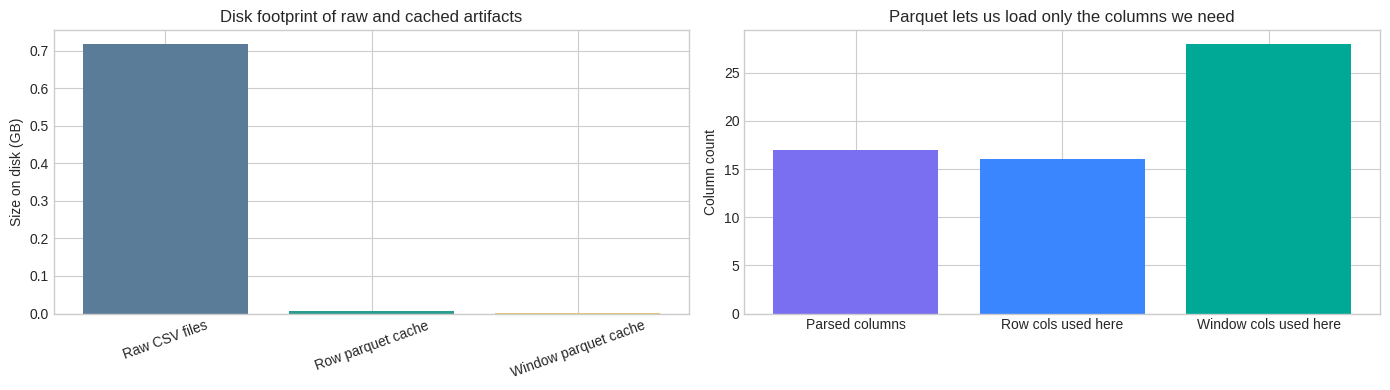

In [9]:
def directory_size_bytes(path: Path, pattern: str) -> int:
    return sum(file_path.stat().st_size for file_path in path.glob(pattern) if file_path.is_file())

cache_paths = choose_cache_paths(
    [PREP_CACHE_ROOT, RUNTIME_CACHE_DIR, READ_CACHE_DIR],
    cache_stem=PREP_CACHE_BUNDLE_NAME or CACHE_BUNDLE_NAME,
)
cache_metadata_path = cache_paths.metadata_path
ROW_CACHE_DIR = str(cache_paths.row_level_dir)
WINDOW_CACHE_PATH = str(cache_paths.window_cache_path)
METADATA_PATH = str(cache_paths.metadata_path)

raw_files = sorted(Path(RAW_DATA_DIR).glob("*.csv"))
row_cache_parts = sorted(Path(ROW_CACHE_DIR).glob("*.parquet"))
if not raw_files:
    raise FileNotFoundError(f"No raw CSV files found in {RAW_DATA_DIR}")
if not row_cache_parts:
    raise FileNotFoundError(f"No parquet parts found in {ROW_CACHE_DIR}")
if not cache_metadata_path.exists():
    raise FileNotFoundError(f"No cache metadata found at {cache_metadata_path}")

cache_metadata = json.loads(cache_metadata_path.read_text())
metadata_measurement_columns = cache_metadata.get("measurement_columns") or []
if metadata_measurement_columns:
    MEASUREMENT_COLUMNS = metadata_measurement_columns
session1_modeling.MEASUREMENT_COLUMNS = MEASUREMENT_COLUMNS.copy()

metadata_qc_columns = set(cache_metadata.get("qc_columns") or [])
OPTIONAL_QC_COLUMNS = [column for column in [TARGET_FLAG, "Temperature QC Flag"] if not metadata_qc_columns or column in metadata_qc_columns]

row_columns_available = set(cache_metadata.get("row_columns") or [])
ROW_USE_COLUMNS = list(dict.fromkeys(["Time UTC", "source_file", *OPTIONAL_QC_COLUMNS, *MEASUREMENT_COLUMNS]))
if row_columns_available:
    ROW_USE_COLUMNS = [column for column in ROW_USE_COLUMNS if column in row_columns_available]

WINDOW_FEATURE_COLUMNS = [
    f"{column}_{stat}"
    for column in MEASUREMENT_COLUMNS
    for stat in ("mean", "std")
]
WINDOW_USE_COLUMNS = [
    "window_start",
    "window_end",
    "source_file",
    "issue_rate",
    *WINDOW_FEATURE_COLUMNS,
]
window_columns_available = set(cache_metadata.get("window_columns") or [])
if window_columns_available:
    WINDOW_USE_COLUMNS = [column for column in WINDOW_USE_COLUMNS if column in window_columns_available]

representative_info = cache_metadata["processed_files"][0]
representative_raw_path = Path(RAW_DATA_DIR) / representative_info["source_file"]
representative_parquet_path = Path(ROW_CACHE_DIR) / Path(representative_info["row_level_part"]).name
header_line_number, parsed_columns = locate_header(representative_raw_path)

with representative_raw_path.open("r", encoding="utf-8") as handle:
    raw_header_preview = [next(handle).rstrip("\n") for _ in range(8)]

raw_total_bytes = directory_size_bytes(Path(RAW_DATA_DIR), "*.csv")
parquet_total_bytes = directory_size_bytes(Path(ROW_CACHE_DIR), "*.parquet")
window_cache_bytes = Path(WINDOW_CACHE_PATH).stat().st_size if Path(WINDOW_CACHE_PATH).exists() else 0

cache_comparison = pd.DataFrame(
    [
        {"artifact": "Raw CSV files", "bytes": raw_total_bytes},
        {"artifact": "Row parquet cache", "bytes": parquet_total_bytes},
        {"artifact": "Window parquet cache", "bytes": window_cache_bytes},
    ]
)
cache_comparison["megabytes"] = cache_comparison["bytes"] / (1024 ** 2)
cache_comparison["gigabytes"] = cache_comparison["bytes"] / (1024 ** 3)
display(cache_comparison)

column_sets = pd.DataFrame(
    [
        {
            "column_set": "Parsed columns from raw CSV",
            "count": len(parsed_columns),
            "examples": ", ".join(parsed_columns[:6]) + (" ..." if len(parsed_columns) > 6 else ""),
        },
        {
            "column_set": "Row columns loaded in this notebook",
            "count": len(ROW_USE_COLUMNS),
            "examples": ", ".join(ROW_USE_COLUMNS[:6]) + (" ..." if len(ROW_USE_COLUMNS) > 6 else ""),
        },
        {
            "column_set": "Window columns loaded in this notebook",
            "count": len(WINDOW_USE_COLUMNS),
            "examples": ", ".join(WINDOW_USE_COLUMNS[:6]) + (" ..." if len(WINDOW_USE_COLUMNS) > 6 else ""),
        },
    ]
)
display(column_sets)

print(
    {
        "cache_bundle_name": cache_metadata.get("cache_stem", CACHE_BUNDLE_NAME),
        "raw_file_count": len(raw_files),
        "parquet_part_count": len(row_cache_parts),
        "metadata_lines_before_table": header_line_number - 1,
        "parsed_column_count": len(parsed_columns),
        "row_columns_used_in_notebook": len(ROW_USE_COLUMNS),
        "window_columns_used_in_notebook": len(WINDOW_USE_COLUMNS),
        "full_row_count": cache_metadata["row_count"],
        "full_window_count": cache_metadata["window_count"],
    }
)
print("Representative raw CSV preview:")
print("\n".join(raw_header_preview))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(cache_comparison["artifact"], cache_comparison["gigabytes"], color=["#5B7C99", "#2A9D8F", "#E9C46A"])
axes[0].set_ylabel("Size on disk (GB)")
axes[0].set_title("Disk footprint of raw and cached artifacts")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(
    ["Parsed columns", "Row cols used here", "Window cols used here"],
    [len(parsed_columns), len(ROW_USE_COLUMNS), len(WINDOW_USE_COLUMNS)],
    color=["#7A6FF0", "#3A86FF", "#00A896"],
)
axes[1].set_ylabel("Column count")
axes[1].set_title("Parquet lets us load only the columns we need")
plt.tight_layout()
plt.show()

,read_path,seconds,rows_loaded,memory_mb,rows_per_second
0,Raw CSV parse,4.720526,1000000,309.944279,2.118408e+05
1,Parquet full load,0.055590,49999,19.311645,8.994320e+05
2,Parquet column-pruned load,0.009378,49999,14.734099,5.331472e+06


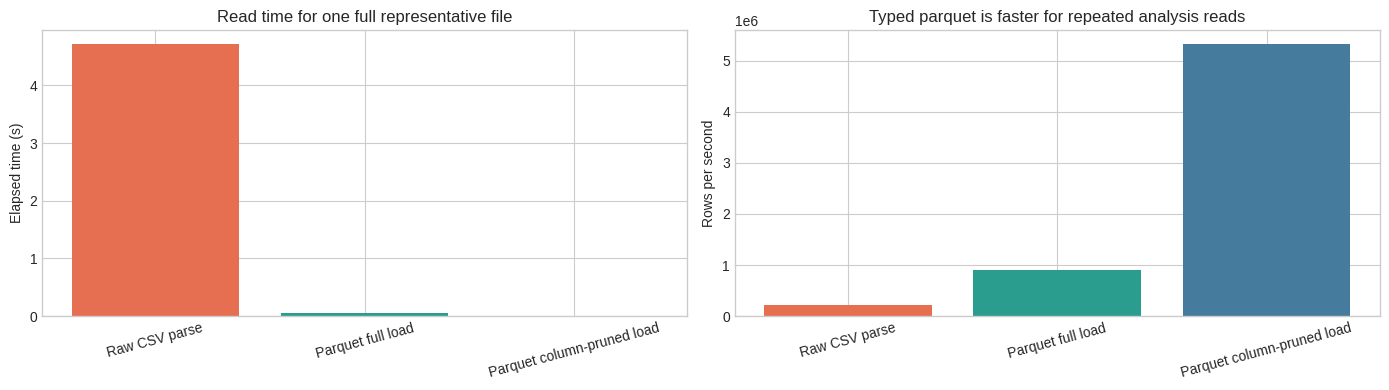

{'csv_seconds': 4.7205, 'parquet_full_seconds': 0.0556, 'parquet_pruned_seconds': 0.0094, 'full_file_speedup_ratio': 84.92, 'column_pruned_speedup_ratio': 503.36}


In [10]:
csv_start = perf_counter()
csv_frame = read_scalar_csv(representative_raw_path, sample_rows=None)
csv_elapsed = perf_counter() - csv_start

parquet_full_start = perf_counter()
parquet_full_frame = pd.read_parquet(representative_parquet_path)
parquet_full_elapsed = perf_counter() - parquet_full_start

parquet_pruned_start = perf_counter()
parquet_pruned_frame = pd.read_parquet(representative_parquet_path, columns=ROW_USE_COLUMNS)
parquet_pruned_elapsed = perf_counter() - parquet_pruned_start

benchmark_summary = pd.DataFrame(
    [
        {
            "read_path": "Raw CSV parse",
            "seconds": csv_elapsed,
            "rows_loaded": len(csv_frame),
            "memory_mb": csv_frame.memory_usage(deep=True).sum() / (1024 ** 2),
        },
        {
            "read_path": "Parquet full load",
            "seconds": parquet_full_elapsed,
            "rows_loaded": len(parquet_full_frame),
            "memory_mb": parquet_full_frame.memory_usage(deep=True).sum() / (1024 ** 2),
        },
        {
            "read_path": "Parquet column-pruned load",
            "seconds": parquet_pruned_elapsed,
            "rows_loaded": len(parquet_pruned_frame),
            "memory_mb": parquet_pruned_frame.memory_usage(deep=True).sum() / (1024 ** 2),
        },
    ]
)
benchmark_summary["rows_per_second"] = benchmark_summary["rows_loaded"] / benchmark_summary["seconds"].clip(lower=1e-9)
display(benchmark_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(benchmark_summary["read_path"], benchmark_summary["seconds"], color=["#E76F51", "#2A9D8F", "#457B9D"])
axes[0].set_ylabel("Elapsed time (s)")
axes[0].set_title("Read time for one full representative file")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(benchmark_summary["read_path"], benchmark_summary["rows_per_second"], color=["#E76F51", "#2A9D8F", "#457B9D"])
axes[1].set_ylabel("Rows per second")
axes[1].set_title("Typed parquet is faster for repeated analysis reads")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

print(
    {
        "csv_seconds": round(csv_elapsed, 4),
        "parquet_full_seconds": round(parquet_full_elapsed, 4),
        "parquet_pruned_seconds": round(parquet_pruned_elapsed, 4),
        "full_file_speedup_ratio": round(csv_elapsed / max(parquet_full_elapsed, 1e-9), 2),
        "column_pruned_speedup_ratio": round(csv_elapsed / max(parquet_pruned_elapsed, 1e-9), 2),
    }
)

## Part 3 — Feature Engineering and Data Loading

Now that the cache is prepared, we can load only the columns we need, inspect time-series examples, and build the row-level features that feed the models.


In [11]:
# Load the metadata that was written during cache preparation.
persistent_cache_paths = choose_cache_paths([READ_CACHE_DIR], cache_stem=CACHE_BUNDLE_NAME)
runtime_cache_paths = choose_cache_paths([RUNTIME_CACHE_DIR], cache_stem=CACHE_BUNDLE_NAME)
active_cache_paths = runtime_cache_paths if runtime_cache_paths.metadata_path.exists() else persistent_cache_paths
CACHE_DIR = str(active_cache_paths.root)
ROW_CACHE_DIR = str(active_cache_paths.row_level_dir)
WINDOW_CACHE_PATH = str(active_cache_paths.window_cache_path)
METADATA_PATH = str(active_cache_paths.metadata_path)

row_cache_dir = Path(ROW_CACHE_DIR)
window_cache_path = Path(WINDOW_CACHE_PATH)
metadata_path = Path(METADATA_PATH)

if not metadata_path.exists():
    raise FileNotFoundError(
        f"Missing cache metadata at {metadata_path}. Run scripts/prepare_scalar_session1_data.py first."
    )

metadata = json.loads(metadata_path.read_text())
if metadata.get("measurement_columns"):
    MEASUREMENT_COLUMNS = metadata["measurement_columns"]
session1_modeling.MEASUREMENT_COLUMNS = MEASUREMENT_COLUMNS.copy()
part_paths = sorted(row_cache_dir.glob("*.parquet"))
if not part_paths:
    raise FileNotFoundError(f"No parquet parts found in {row_cache_dir}")

# Choose parquet parts spread across the full year.
selected_paths = select_part_paths(part_paths, limit=ROW_FILE_LIMIT, mode=PART_SELECTION_MODE)
part_to_source = {
    Path(file_info["row_level_part"]).name: file_info["source_file"]
    for file_info in metadata["processed_files"]
}
source_to_row_part = {
    file_info["source_file"]: file_info["row_level_part"]
    for file_info in metadata["processed_files"]
}
selected_source_files = {part_to_source[path.name] for path in selected_paths}

print(
    {
        "active_cache_dir": str(active_cache_paths.root),
        "cache_bundle_name": metadata.get("cache_stem", CACHE_BUNDLE_NAME),
        "persistent_cache_dir": str(persistent_cache_paths.root),
        "runtime_output_root": str(RUNTIME_OUTPUT_ROOT),
        "model_output_dir": str(MODEL_OUTPUT_DIR),
    }
)

{'active_cache_dir': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/cache/session1', 'cache_bundle_name': 'fluorometer_scalar_session1', 'persistent_cache_dir': '/project/6062898/shared/daqathon/data/cache/session1', 'runtime_output_root': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs', 'model_output_dir': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/models'}


In [12]:
# Summarize the overall cache before loading row samples.
cache_summary = {
    "full_row_count": metadata["row_count"],
    "full_window_count": metadata["window_count"],
    "processed_file_count": metadata["processed_file_count"],
    "issue_fraction": round(float(metadata["issue_fraction"]), 4),
    "task_mode": TASK_MODE,
}
print(cache_summary)

selected_file_summary = pd.DataFrame(metadata["processed_files"])
selected_file_summary = selected_file_summary[selected_file_summary["source_file"].isin(selected_source_files)].reset_index(drop=True)
selected_file_summary = selected_file_summary[["source_file", "row_count", "time_start", "time_end"]].copy()
selected_file_summary["source_file"] = selected_file_summary["source_file"].str.replace(
    r"_\d{8}T\d{6}Z_\d{8}T\d{6}Z-NaN\.csv$",
    "",
    regex=True,
)
display(selected_file_summary.head(5))


{'full_row_count': 149997, 'full_window_count': 588, 'processed_file_count': 3, 'issue_fraction': 0.0143, 'task_mode': 'multiclass'}


,source_file,row_count,time_start,time_end
0,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,49999,2025-04-01T00:00:00.052000+00:00,2025-04-01T13:53:18.811000+00:00
1,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,49999,2025-04-12T13:46:55.824000+00:00,2025-04-13T03:40:14.571000+00:00
2,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,49999,2025-04-24T03:33:52.052000+00:00,2025-04-24T17:27:10.762000+00:00


### 🚚 Loading More Data Efficiently

In this notebook we want to use **as much useful data as possible** without turning every cell into a slow I/O bottleneck.

The easiest control is `DATA_FRACTION` in the configuration cell:

- set `DATA_FRACTION = 0.1` for a quick live demo,
- set `DATA_FRACTION = 0.25` or `0.5` for a medium run,
- set `DATA_FRACTION = 1.0` to use the largest local profile we prepared for this workshop.

The strategy is different for the two model families:

- **Tree models** such as Random Forest still want one in-memory feature matrix, so we make that matrix more efficient by reading parquet instead of raw CSV, pruning unused columns, and sampling across the full year instead of only the first files.
- **Neural networks** can train in mini-batches, so later we will use a PyTorch `DataLoader` to stream batches to the GPU instead of pushing the whole dataset through the device at once.

For the row-level cache we do three important things:

- choose parquet parts spread across the whole time range,
- read only the columns this notebook actually needs,
- keep extra non-`1` rows so rare QC cases are still visible in the training set.


### 🎚️ Data Loading Controls

These settings control how much of the cached dataset we load for the supervised and unsupervised sections.

Main variables:

- `ROWS_PER_FILE`: how many row-level samples to keep from each parquet part.
- `ISSUE_ROWS_PER_FILE`: extra non-`1` QC rows to keep so rarer flags still appear.
- `MODEL_ROW_LIMIT`: final cap on the tabular training frame used by the Random Forest.

Common alternatives:

- increase these values when you want stronger models and have more time,
- decrease them for a quick live demo,
- set `ROW_FILE_LIMIT` to a small number only if you intentionally want to use fewer source files.


In [13]:
ROWS_PER_FILE = max(5000, int(BASE_ROWS_PER_FILE * DATA_FRACTION))
ISSUE_ROWS_PER_FILE = max(1000, int(BASE_ISSUE_ROWS_PER_FILE * DATA_FRACTION))
MODEL_ROW_LIMIT = max(100000, int(BASE_MODEL_ROW_LIMIT * DATA_FRACTION))

print(
    {
        "ROWS_PER_FILE": ROWS_PER_FILE,
        "ISSUE_ROWS_PER_FILE": ISSUE_ROWS_PER_FILE,
        "MODEL_ROW_LIMIT": MODEL_ROW_LIMIT,
    }
)


{'ROWS_PER_FILE': 45000, 'ISSUE_ROWS_PER_FILE': 12000, 'MODEL_ROW_LIMIT': 1000000}


In [14]:
# Load only the row-level columns we will actually use for plotting and supervised learning.
df = load_row_level_sample(
    selected_paths,
    rows_per_file=ROWS_PER_FILE,
    issue_rows_per_file=ISSUE_ROWS_PER_FILE,
    target_flag=TARGET_FLAG,
    columns=ROW_USE_COLUMNS,
)

# Load the cached window summaries for clustering, again with column pruning.
window_df = pd.read_parquet(window_cache_path, columns=WINDOW_USE_COLUMNS)
window_df["window_start"] = pd.to_datetime(window_df["window_start"], utc=True)
window_df["window_end"] = pd.to_datetime(window_df["window_end"], utc=True)
window_df = (
    window_df[window_df["source_file"].isin(selected_source_files)]
    .sort_values("window_start")
    .reset_index(drop=True)
)
window_limit = None if DATA_FRACTION >= 0.999 else max(2000, int(len(window_df) * DATA_FRACTION))
window_df = evenly_spaced_take(window_df, window_limit)

print(
    {
        "selected_parts": len(selected_paths),
        "loaded_rows": len(df),
        "loaded_windows": len(window_df),
        "data_fraction": DATA_FRACTION,
        "row_columns_loaded": len(ROW_USE_COLUMNS),
        "window_columns_loaded": len(WINDOW_USE_COLUMNS),
        "rows_per_file": ROWS_PER_FILE,
        "issue_rows_per_file": ISSUE_ROWS_PER_FILE,
        "window_limit": window_limit,
    }
)


{'selected_parts': 3, 'loaded_rows': 99721, 'loaded_windows': 588, 'data_fraction': 1.0, 'row_columns_loaded': 16, 'window_columns_loaded': 28, 'rows_per_file': 45000, 'issue_rows_per_file': 12000, 'window_limit': None}


In [15]:
# Look at a few rows so we can connect the description to the actual table.

#example = 'FluorometerExample'

if example == 'ConductivityTestExample':
    preview_candidates = [
        "Time UTC",
        "Conductivity (S/m)",
        "Temperature (C)",
        "Depth (m)",
        "Conductivity QC Flag",
        "Temperature QC Flag",
    ]
elif example == 'FluorometerExample':
    preview_candidates = [
        "Time UTC",
        "Turbidity (NTU)",
        "Temperature (C)",
        "Depth (m)",
        "Turbidity QC Flag",
        "Temperature QC Flag",
    ]

preview_columns = [column for column in preview_candidates if column in df.columns]
display(df[preview_columns].head(8))
print(
    {
        "time_start": df["Time UTC"].min().isoformat(),
        "time_end": df["Time UTC"].max().isoformat(),
        "preview_columns": preview_columns,
    }
)


,Time UTC,Turbidity (NTU),Temperature (C),Turbidity QC Flag,Temperature QC Flag
0,2025-04-01 00:00:00.052000+00:00,1.5958,9.3717,1.0,1.0
1,2025-04-01 00:00:01.052000+00:00,1.5150,9.3716,1.0,1.0
2,2025-04-01 00:00:03.058000+00:00,1.5150,9.3716,1.0,1.0
3,2025-04-01 00:00:04.052000+00:00,1.5352,9.3716,1.0,1.0
4,2025-04-01 00:00:06.052000+00:00,1.6564,9.3716,1.0,1.0
5,2025-04-01 00:00:07.054000+00:00,1.5958,9.3716,1.0,1.0
6,2025-04-01 00:00:09.052000+00:00,1.6766,9.3716,1.0,1.0
7,2025-04-01 00:00:10.052000+00:00,1.7170,9.3716,1.0,1.0


{'time_start': '2025-04-01T00:00:00.052000+00:00', 'time_end': '2025-04-24T17:27:10.762000+00:00', 'preview_columns': ['Time UTC', 'Turbidity (NTU)', 'Temperature (C)', 'Turbidity QC Flag', 'Temperature QC Flag']}


### Seeing The QC Flags In Context

Before we train anything, it helps to look at the time series directly.

The plots below show short windows centred on representative rows with different QC flags. This is useful because:

- it connects the abstract label numbers to real sensor behaviour,
- it shows that some problematic labels appear in coherent stretches rather than isolated single rows,
- it reminds us that the model is trying to learn from patterns in time, not from labels in isolation.

If you want to make these panels wider or more annotated during the session, the config cell exposes:

- `FLAG_EXAMPLE_POINTS_PER_PANEL`
- `FLAG_EXAMPLE_REGION_ALPHA`
- `FLAG_EXAMPLE_SHOW_POINTS`
- `FLAG_EXAMPLE_CLASSES`


In [16]:
FLAG_EXAMPLE_POINTS_PER_PANEL = BASE_FLAG_EXAMPLE_POINTS_PER_PANEL
FLAG_EXAMPLE_REGION_ALPHA = 0.18
FLAG_EXAMPLE_SHOW_POINTS = False
FLAG_EXAMPLE_CLASSES = (1, 3, 4, 9)

print(
    {
        "FLAG_EXAMPLE_POINTS_PER_PANEL": FLAG_EXAMPLE_POINTS_PER_PANEL,
        "FLAG_EXAMPLE_REGION_ALPHA": FLAG_EXAMPLE_REGION_ALPHA,
        "FLAG_EXAMPLE_SHOW_POINTS": FLAG_EXAMPLE_SHOW_POINTS,
        "FLAG_EXAMPLE_CLASSES": FLAG_EXAMPLE_CLASSES,
    }
)


{'FLAG_EXAMPLE_POINTS_PER_PANEL': 30000, 'FLAG_EXAMPLE_REGION_ALPHA': 0.18, 'FLAG_EXAMPLE_SHOW_POINTS': False, 'FLAG_EXAMPLE_CLASSES': (1, 3, 4, 9)}


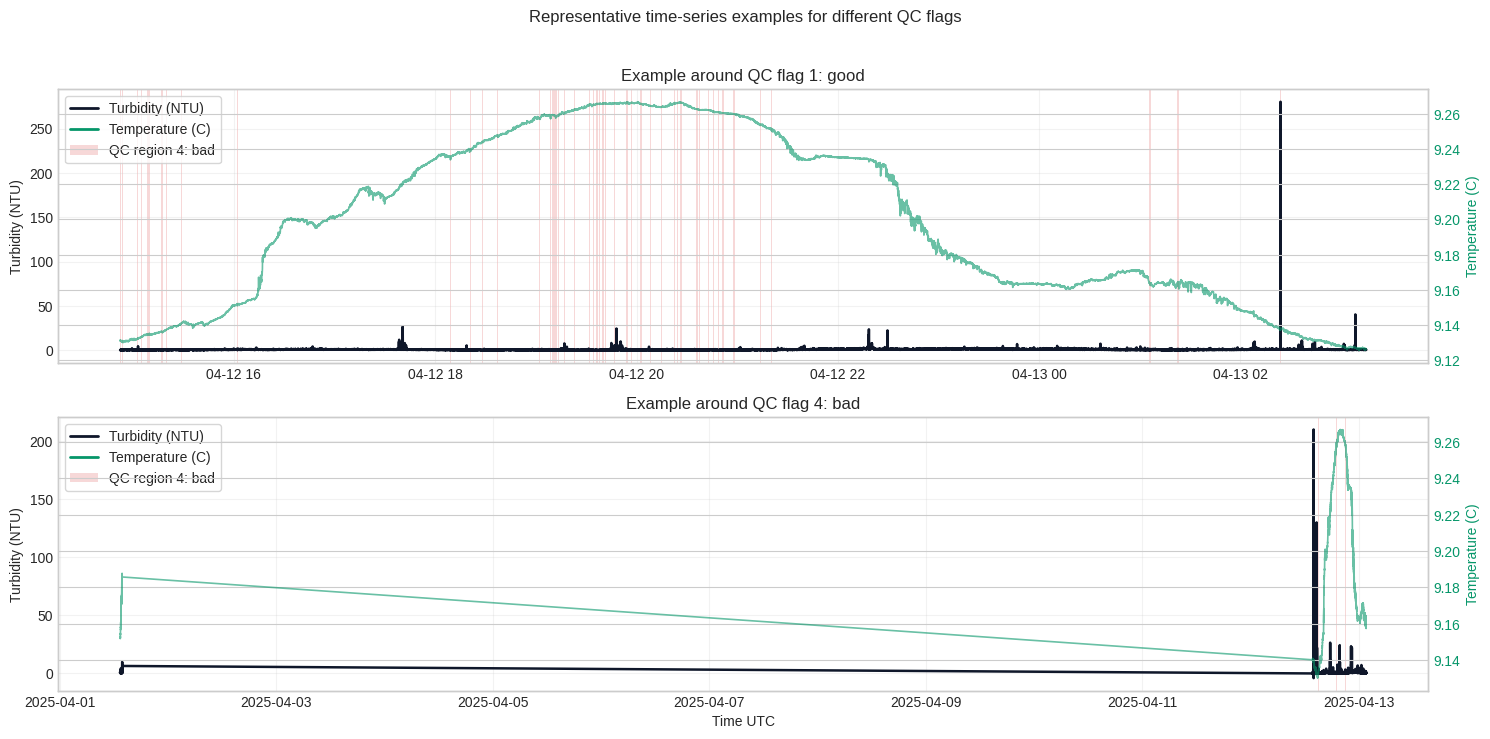

,qc_flag,meaning,panel_start,panel_end,example_time,source_file
0,1,good,2025-04-12 14:52:10.882000+00:00,2025-04-13 03:14:55.544000+00:00,2025-04-12 20:57:04.225000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...
1,4,bad,2025-04-01 13:25:05.784000+00:00,2025-04-13 01:39:22.471000+00:00,2025-04-12 19:28:17.167000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...


In [ ]:
# Plot representative local windows for the main QC flag values we see in this dataset.
timeseries_figure, timeseries_examples = plot_flag_examples(
    df,
    target_flag=TARGET_FLAG,
    measurement_column=measurement_column_str,
    secondary_column=secondary_column_str,
    #measurement_column="Conductivity (S/m)",
    #secondary_column="Temperature (C)",
    points_per_panel=FLAG_EXAMPLE_POINTS_PER_PANEL,
    classes=FLAG_EXAMPLE_CLASSES,
    region_alpha=FLAG_EXAMPLE_REGION_ALPHA,
    show_flag_points=FLAG_EXAMPLE_SHOW_POINTS,
)
plt.show()
display(timeseries_examples)


,QC flag,Meaning
0,0,no QC
1,1,good
2,2,probably good
3,3,probably bad
4,4,bad
5,6,bad down-sampling
6,7,averaged
7,8,interpolated
8,9,missing / NaN


,full_cache,loaded_sample
1,147848,97572
4,2149,2149


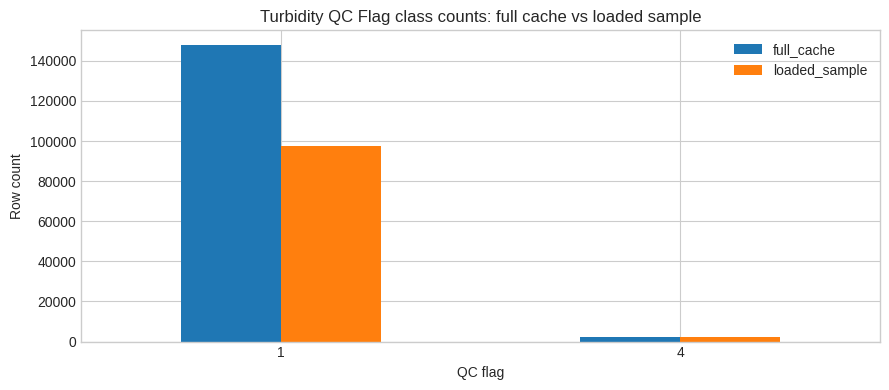

{'active_target': 'Turbidity QC Flag', 'task_mode': 'multiclass'}


In [18]:
# Compare the full-cache target distribution with the sampled training distribution.
full_target_counts = pd.Series({int(key): int(value) for key, value in metadata["target_distribution"].items()}).sort_index()
sample_target_counts = df[TARGET_FLAG].dropna().astype(int).value_counts().sort_index()
task_mode = TASK_MODE.lower().strip()
if task_mode not in {"multiclass", "binary"}:
    raise ValueError(f"Unsupported TASK_MODE: {TASK_MODE}")
target_name = TARGET_FLAG if task_mode == "multiclass" else "issue"

flag_meanings = pd.DataFrame(
    {
        "QC flag": [0, 1, 2, 3, 4, 6, 7, 8, 9],
        "Meaning": [
            "no QC",
            "good",
            "probably good",
            "probably bad",
            "bad",
            "bad down-sampling",
            "averaged",
            "interpolated",
            "missing / NaN",
        ],
    }
)
display(flag_meanings)
distribution_frame = pd.DataFrame({
    "full_cache": full_target_counts,
    "loaded_sample": sample_target_counts,
}).fillna(0).astype(int)
display(distribution_frame)
distribution_frame.plot(kind="bar", figsize=(9, 4), title=f"{TARGET_FLAG} class counts: full cache vs loaded sample")
plt.xlabel("QC flag")
plt.ylabel("Row count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print({"active_target": target_name, "task_mode": task_mode})


### 🧪 Turning The Scalar Data Stream Into Model Features

A machine-learning model does not automatically know that this is a time series from a CTD instrument. We have to decide what each training example looks like.

For the **Random Forest baseline**, we convert the data into a **tabular** problem where each row is one example. We include:

- the raw CTD and derived measurements,
- simple clock features such as hour and day of year,
- `abs_delta` features that measure how sharply each variable changed from the previous row.

This is a useful first step because it is simple, fast, and easy to inspect. It also gives us a good reference point before we try more sophisticated ideas.


In [19]:
# Reuse the centrally defined measurement list from the configuration cell.
measurement_columns = MEASUREMENT_COLUMNS.copy()

# Start from the efficiently loaded row-level frame.
model_df = df.copy()
model_df["issue"] = model_df[TARGET_FLAG].isin([3, 4, 9]).astype(int)
model_df["hour_utc"] = model_df["Time UTC"].dt.hour
model_df["minute_utc"] = model_df["Time UTC"].dt.minute
model_df["day_of_year"] = model_df["Time UTC"].dt.dayofyear

# Add simple change features so the model can react to sudden local jumps.
for column in measurement_columns:
    engineered_name = f"{column} abs_delta"
    model_df[engineered_name] = model_df[column].diff().abs().fillna(0.0)

feature_columns = measurement_columns + [
    f"{column} abs_delta" for column in measurement_columns
] + ["hour_utc", "minute_utc", "day_of_year"]

model_df = model_df.dropna(subset=[TARGET_FLAG]).reset_index(drop=True)
if MODEL_ROW_LIMIT is not None and len(model_df) > MODEL_ROW_LIMIT:
    # This final cap is scaled by DATA_FRACTION so the whole notebook can be sped up from one variable.
    model_df = evenly_spaced_take(model_df, MODEL_ROW_LIMIT)

model_df["model_target"] = (
    model_df[TARGET_FLAG].astype(int)
    if task_mode == "multiclass"
    else model_df["issue"].astype(int)
)
active_labels = sorted(model_df["model_target"].dropna().astype(int).unique().tolist())

display(model_df[["Time UTC", TARGET_FLAG, "issue", *measurement_columns[:4]]].head(8))
print({"model_rows": len(model_df), "active_labels": active_labels, "feature_count": len(feature_columns)})


,Time UTC,Turbidity QC Flag,issue,Chlorophyll (ug/l),Turbidity (NTU),Conductivity (S/m),Density (kg/m3)
0,2025-04-01 00:00:00.052000+00:00,1.0,0,-0.1666,1.5958,3.38547,1025.383452
1,2025-04-01 00:00:01.052000+00:00,1.0,0,-0.1666,1.5150,3.38548,1025.383628
2,2025-04-01 00:00:03.058000+00:00,1.0,0,-0.1617,1.5150,3.38548,1025.383628
3,2025-04-01 00:00:04.052000+00:00,1.0,0,-0.1617,1.5352,3.38547,1025.383624
4,2025-04-01 00:00:06.052000+00:00,1.0,0,-0.1617,1.6564,3.38548,1025.383555
5,2025-04-01 00:00:07.054000+00:00,1.0,0,-0.1421,1.5958,3.38547,1025.383550
6,2025-04-01 00:00:09.052000+00:00,1.0,0,-0.1617,1.6766,3.38547,1025.383550
7,2025-04-01 00:00:10.052000+00:00,1.0,0,-0.1568,1.7170,3.38546,1025.383477


{'model_rows': 99721, 'active_labels': [1, 4], 'feature_count': 27}


## Part 4 — Random Forest

We start with a strong tabular baseline: one row becomes one supervised example, and the forest learns to separate QC classes from engineered numeric features.


### 🌲 Supervised Learning: Random Forest

A **Random Forest** is an ensemble of many decision trees.

Here is the basic idea:

1. make many slightly different training samples from the data,
2. train one decision tree on each sample,
3. let the trees vote on the final class.

Each tree asks simple if/then questions such as:

- is conductivity above some threshold?
- did temperature change sharply?
- is the measurement happening at a particular time of day?

Why this is a good Session 1 model:

- it works well on numeric tabular data,
- it usually needs less feature scaling ceremony than many other models,
- it gives us interpretable outputs such as feature importance.

Limits to keep in mind:

- it does not naturally understand long sequential context,
- it only learns from the features we explicitly give it,
- rare classes can still be difficult.

We also use a **contiguous** train/validation/test split rather than shuffling. That matters for time series because we want the model to be tested on later periods, not on randomly mixed timestamps from the same local run.


![Random Forest bagging illustration](../assets/session1/random_forest_bagging_illustration.png)

Diagram idea: bootstrap samples are drawn from the original dataset, separate trees are trained, and their predictions are aggregated into one model decision.

Image credit: Harry585, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Random Forest Bagging Illustration.png](https://commons.wikimedia.org/wiki/File:Random_Forest_Bagging_Illustration.png)


In [29]:
# Split in time order: earliest -> train, middle -> validation, latest -> test.
train_df, valid_df, test_df = contiguous_split(model_df, TRAIN_FRACTION, VALIDATION_FRACTION)

X_train = train_df[feature_columns]
y_train = train_df["model_target"]
X_valid = valid_df[feature_columns]
y_valid = valid_df["model_target"]
X_test = test_df[feature_columns]
y_test = test_df["model_target"]

print({
    "train_rows": len(train_df),
    "validation_rows": len(valid_df),
    "test_rows": len(test_df),
    "train_time_span": [train_df['Time UTC'].min().isoformat(), train_df['Time UTC'].max().isoformat()],
    "test_time_span": [test_df['Time UTC'].min().isoformat(), test_df['Time UTC'].max().isoformat()],
})


{'train_rows': 69804, 'validation_rows': 14958, 'test_rows': 14959, 'train_time_span': ['2025-04-01T00:00:00.052000+00:00', '2025-04-24T04:52:52.190000+00:00'], 'test_time_span': ['2025-04-24T11:10:37.411000+00:00', '2025-04-24T17:27:10.762000+00:00']}


### Random Forest Settings

These settings control the baseline forest we train below.

Main variables:

- `n_estimators`: number of trees in the forest.
- `max_depth`: maximum depth of each tree. `None` means grow until other stopping rules apply.
- `min_samples_leaf`: minimum number of samples allowed in a leaf.
- `min_samples_split`: minimum number of samples needed to split an internal node.
- `max_features`: how many features each split is allowed to consider. Common choices are `"sqrt"`, `"log2"`, or `None`.
- `class_weight`: how strongly to compensate for imbalance. Common choices are `None`, `"balanced"`, and `"balanced_subsample"`.
- `trees_per_step`: how many trees to add each time we print progress.

Forests do **not** train epoch-by-epoch like neural networks. To make progress visible, we grow the forest in chunks using `warm_start=True` and print the validation F1 after each chunk.

One practical note: when we use `warm_start=True`, this notebook converts `"balanced"` or `"balanced_subsample"` into one fixed class-weight dictionary computed from `y_train`. That avoids a scikit-learn warning and keeps the weighting consistent across growth steps.


In [30]:
RF_CONFIG = {
    "imputer_strategy": "median",
    "n_estimators": 200,
    "trees_per_step": 25,
    "max_depth": None,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "max_features": "sqrt",
    "class_weight": "balanced_subsample",
    "verbose": 0,
}

display(pd.Series(RF_CONFIG, name="value").rename_axis("rf_parameter").to_frame())


,value
rf_parameter,
imputer_strategy,median
n_estimators,200
trees_per_step,25
max_depth,None
min_samples_leaf,2
min_samples_split,2
max_features,sqrt
class_weight,balanced_subsample
verbose,0


In [34]:
# Step 1: fit the imputer once on training data and reuse it for validation/test.
rf_imputer = SimpleImputer(strategy=RF_CONFIG.get("imputer_strategy", "median"))
X_train_rf = rf_imputer.fit_transform(X_train)
X_valid_rf = rf_imputer.transform(X_valid)
X_test_rf = rf_imputer.transform(X_test)

# Step 2: compute one stable class-weight dictionary for the whole training split.
requested_class_weight = RF_CONFIG.get("class_weight")
if requested_class_weight in {"balanced", "balanced_subsample"}:
    rf_classes = np.array(sorted(pd.Series(y_train).dropna().unique()))
    rf_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=rf_classes,
        y=y_train,
    )
    effective_class_weight = {
        int(label) if isinstance(label, (np.integer, int)) else label: float(weight)
        for label, weight in zip(rf_classes.tolist(), rf_weight_values.tolist())
    }
else:
    effective_class_weight = requested_class_weight

print(
    {
        "requested_class_weight": requested_class_weight,
        "effective_class_weight": effective_class_weight,
    }
)

# Step 3: build the forest itself. We use warm_start so we can grow it in chunks and print progress.
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["trees_per_step"],
    warm_start=True,
    max_depth=RF_CONFIG["max_depth"],
    min_samples_leaf=RF_CONFIG["min_samples_leaf"],
    min_samples_split=RF_CONFIG["min_samples_split"],
    max_features=RF_CONFIG["max_features"],
    class_weight=effective_class_weight,
    n_jobs=-1,
    random_state=SEED,
    verbose=RF_CONFIG["verbose"],
)

rf_progress_rows = []
total_trees = RF_CONFIG["n_estimators"]
trees_per_step = RF_CONFIG["trees_per_step"]
growth_schedule = list(range(trees_per_step, total_trees + 1, trees_per_step))
if not growth_schedule:
    growth_schedule = [total_trees]
elif growth_schedule[-1] != total_trees:
    growth_schedule.append(total_trees)

for tree_count in growth_schedule:
    rf_model.set_params(n_estimators=tree_count)
    rf_model.fit(X_train_rf, y_train)
    current_valid_predictions = rf_model.predict(X_valid_rf)
    current_valid_f1 = f1_score(
        y_valid,
        current_valid_predictions,
        average=report_average(task_mode),
        zero_division=0,
    )
    rf_progress_rows.append({"trees_built": tree_count, "validation_f1": float(current_valid_f1)})
    print(f"Built {tree_count:>3} trees | validation F1 = {current_valid_f1:.4f}")

# Step 4: wrap the fitted pieces into a reusable sklearn pipeline object.
rf_pipeline = Pipeline(
    steps=[
        ("imputer", rf_imputer),
        ("model", rf_model),
    ]
)

valid_predictions = rf_pipeline.predict(X_valid)
test_predictions = rf_pipeline.predict(X_test)
labels = sorted(pd.unique(pd.concat([y_train, y_valid, y_test])))

display(pd.DataFrame(rf_progress_rows))

with RF_MODEL_PATH.open("wb") as handle:
    pickle.dump(
        {
            "pipeline": rf_pipeline,
            "feature_columns": feature_columns,
            "labels": labels,
            "task_mode": task_mode,
        },
        handle,
    )

print({"saved_random_forest_model": str(RF_MODEL_PATH)})


{'requested_class_weight': 'balanced_subsample', 'effective_class_weight': {1: 0.5147863537810292, 4: 17.407481296758103}}
Built  25 trees | validation F1 = 1.0000
Built  50 trees | validation F1 = 1.0000
Built  75 trees | validation F1 = 1.0000
Built 100 trees | validation F1 = 1.0000
Built 125 trees | validation F1 = 1.0000
Built 150 trees | validation F1 = 1.0000
Built 175 trees | validation F1 = 1.0000
Built 200 trees | validation F1 = 1.0000


,trees_built,validation_f1
0,25,1.0
1,50,1.0
2,75,1.0
3,100,1.0
4,125,1.0
5,150,1.0
6,175,1.0
7,200,1.0


{'saved_random_forest_model': '/localscratch/slonimer.35007498.0/daqathon/session1_outputs/models/best_random_forest.pkl'}


Validation macro/binary F1: 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     14958
           4       0.00      0.00      0.00         0

    accuracy                           1.00     14958
   macro avg       0.50      0.50      0.50     14958
weighted avg       1.00      1.00      1.00     14958

Test macro/binary F1: 0.9947
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     14815
           4       1.00      0.98      0.99       144

    accuracy                           1.00     14959
   macro avg       1.00      0.99      0.99     14959
weighted avg       1.00      1.00      1.00     14959



,split,f1
0,validation,1.0000
1,test,0.9947


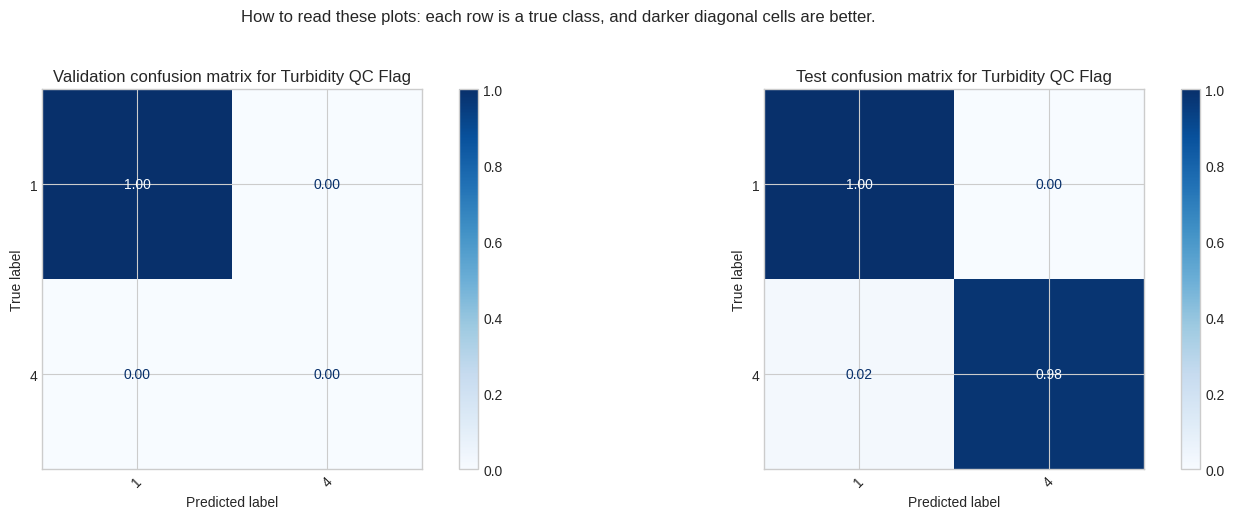

In [47]:
# Report validation and test metrics separately.
metric_rows = []
for split_name, y_true, y_pred in [
    ("validation", y_valid, valid_predictions),
    ("test", y_test, test_predictions),
]:
    split_f1 = f1_score(y_true, y_pred, average=report_average(task_mode), zero_division=0)
    metric_rows.append({"split": split_name, "f1": round(float(split_f1), 4)})
    print(f"{split_name.title()} macro/binary F1: {split_f1:.4f}")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

display(pd.DataFrame(metric_rows))

# Plot normalized confusion matrices for both validation and test.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    labels=labels,
    display_labels=[str(label) for label in labels],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=axes[0],
)
axes[0].set_title(f"Validation confusion matrix for {target_name}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=labels,
    display_labels=[str(label) for label in labels],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=axes[1],
)
axes[1].set_title(f"Test confusion matrix for {target_name}")
fig.suptitle("How to read these plots: each row is a true class, and darker diagonal cells are better.", y=1.03)
plt.tight_layout()
plt.show()


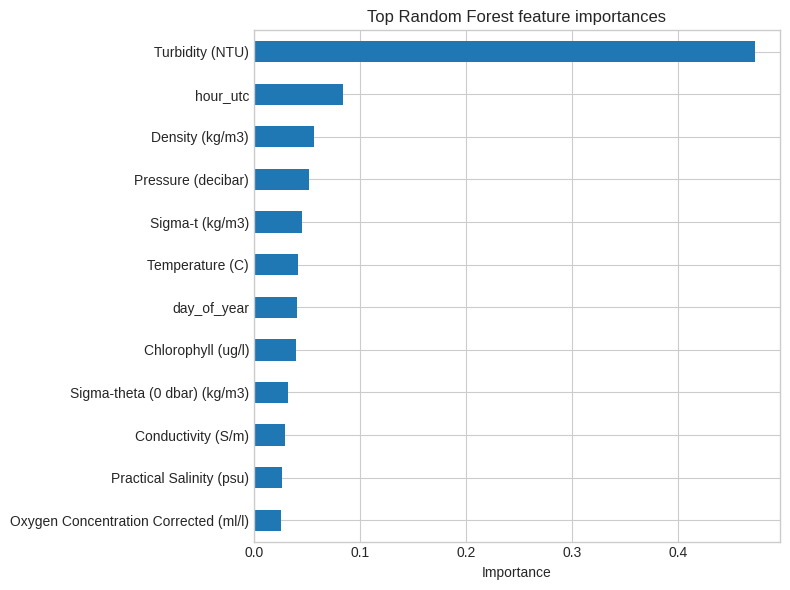

,importance
Turbidity (NTU),0.472178
hour_utc,0.083746
Density (kg/m3),0.056576
Pressure (decibar),0.051746
Sigma-t (kg/m3),0.044991
Temperature (C),0.041526
day_of_year,0.040342
Chlorophyll (ug/l),0.039829
Sigma-theta (0 dbar) (kg/m3),0.031770
Conductivity (S/m),0.029114


{'test_errors_shown': 3, 'test_error_rate': 0.0002}


,Time UTC,Turbidity QC Flag,issue,Turbidity (NTU),Temperature (C),Density (kg/m3),prediction,correct
95136,2025-04-24 15:32:35.640000+00:00,4.0,1,262.3980,9.3023,1025.341062,1,False
95137,2025-04-24 15:32:36.645000+00:00,4.0,1,120.4526,9.3024,1025.341041,1,False
95138,2025-04-24 15:32:37.641000+00:00,4.0,1,27.0680,9.3025,1025.341108,1,False


In [ ]:
# Feature importance tells us which columns the forest used most strongly.
feature_importances = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_,
    index=feature_columns,
).sort_values(ascending=False)

top_importances = feature_importances.head(12).sort_values()
top_importances.plot(kind="barh", figsize=(8, 6), title="Top Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
display(feature_importances.head(12).rename("importance").to_frame())

# Show a few test-set mistakes to ground the discussion in real timestamps.
# TODO: Adjust the test_df "keys" as appropriate for Random Forest results
error_frame = test_df[["Time UTC", TARGET_FLAG, "issue", "Turbidity (NTU)", "Temperature (C)", "Density (kg/m3)"]].copy()
#error_frame = test_df[["Time UTC", TARGET_FLAG, "issue", "Conductivity (S/m)", "Temperature (C)", "Depth (m)"]].copy()
error_frame["prediction"] = test_predictions
error_frame["correct"] = error_frame["prediction"] == y_test.to_numpy()
error_examples = error_frame.loc[~error_frame["correct"]].head(12)
print({"test_errors_shown": len(error_examples), "test_error_rate": round(float((~error_frame["correct"]).mean()), 4)})
display(error_examples)


### Date-Range Demo: Predict QC Flags with the Random Forest

The test-set metrics above summarize performance across the whole held-out split. This mini-workflow asks a more concrete question:

**What does the Random Forest predict on one specific interval of time?**

Use UTC strings such as `"2025-09-10 00:00:00Z"` if you want to override the default range.


In [32]:
RF_RANGE_START = None
RF_RANGE_END = None
RF_AUTO_SELECT_TEST_RANGE = True
RF_MAX_POINTS_TO_PLOT = 800

print(
    {
        "RF_RANGE_START": RF_RANGE_START,
        "RF_RANGE_END": RF_RANGE_END,
        "RF_AUTO_SELECT_TEST_RANGE": RF_AUTO_SELECT_TEST_RANGE,
        "RF_MAX_POINTS_TO_PLOT": RF_MAX_POINTS_TO_PLOT,
    }
)


{'RF_RANGE_START': None, 'RF_RANGE_END': None, 'RF_AUTO_SELECT_TEST_RANGE': True, 'RF_MAX_POINTS_TO_PLOT': 800}


{'selection_mode': 'auto', 'selected_priority_flag': 4, 'interval_origin': 'test', 'range_start': '2025-04-24T16:42:58.733000+00:00', 'range_end': '2025-04-24T17:02:22.742000+00:00', 'rows_in_interval': 1165, 'interval_f1': 1.0}
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1083
           4       1.00      1.00      1.00        82

    accuracy                           1.00      1165
   macro avg       1.00      1.00      1.00      1165
weighted avg       1.00      1.00      1.00      1165



,true_count,predicted_count
1,1083,1083
4,82,82


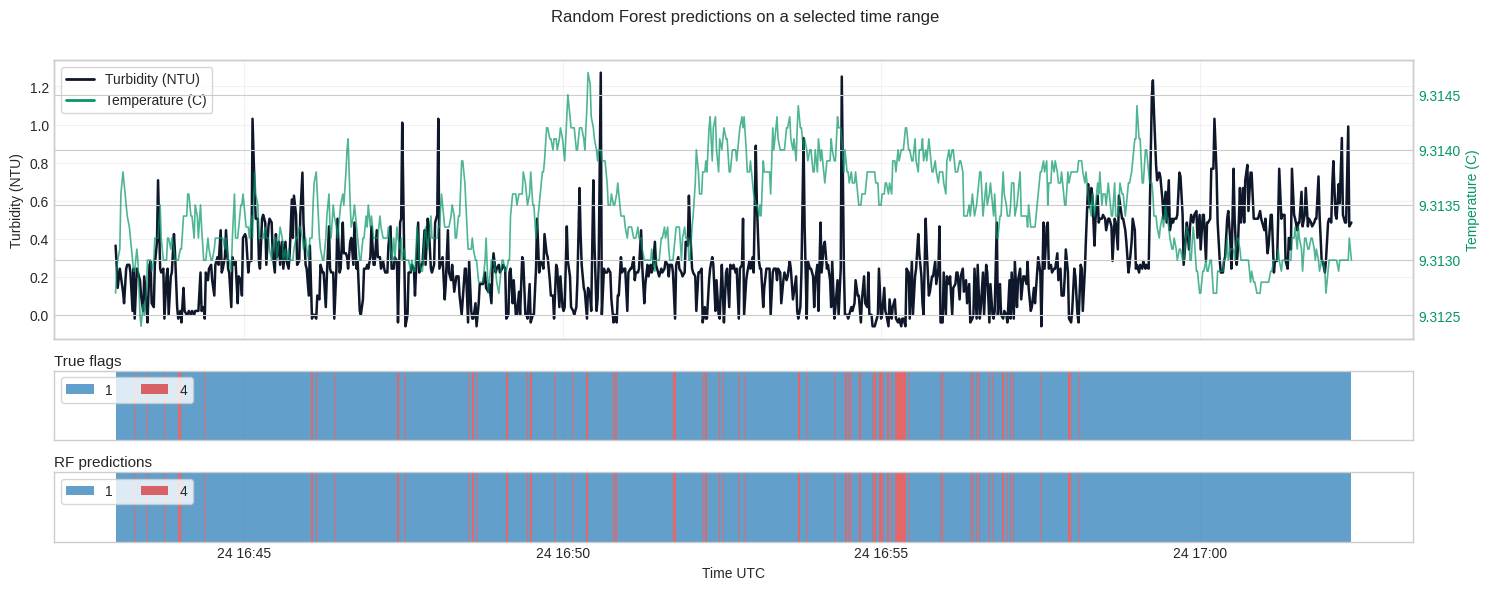

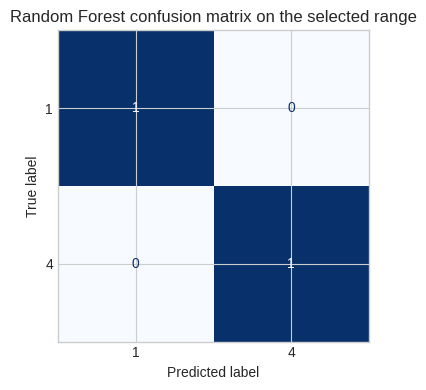

In [ ]:
rf_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=RF_RANGE_START,
    end=RF_RANGE_END,
    auto_select=RF_AUTO_SELECT_TEST_RANGE,
    max_points=RF_MAX_POINTS_TO_PLOT,
)

rf_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=rf_range_selection["start"],
    end=rf_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)

if rf_interval_rows.empty:
    print("No row-level data was found in the requested Random Forest range.")
else:
    rf_interval_model_df, _, _ = build_model_frame(
        rf_interval_rows,
        target_flag=TARGET_FLAG,
        task_mode=task_mode,
        model_row_limit=None,
    )
    rf_interval_model_df = rf_interval_model_df[
        (rf_interval_model_df["Time UTC"] >= rf_range_selection["start"])
        & (rf_interval_model_df["Time UTC"] <= rf_range_selection["end"])
    ].reset_index(drop=True)

    if rf_interval_model_df.empty:
        print("The selected Random Forest range did not contain usable labeled rows after preparation.")
    else:
        rf_interval_predictions = rf_pipeline.predict(rf_interval_model_df[feature_columns])
        rf_interval_origin = infer_interval_origin(
            rf_range_selection["start"],
            rf_range_selection["end"],
            {"train": train_df, "validation": valid_df, "test": test_df},
        )
        rf_interval_metrics = compute_interval_classification_metrics(
            rf_interval_model_df["model_target"],
            rf_interval_predictions,
            labels=labels,
            average=report_average(task_mode),
            target_names=[str(label) for label in labels],
        )
        rf_plot_palette = DEFAULT_FLAG_PALETTE if task_mode == "multiclass" else {0: "#1f77b4", 1: "#d62728"}
        rf_true_intervals = build_labeled_intervals(
            rf_interval_model_df,
            time_column="Time UTC",
            label_column="model_target",
        )
        rf_pred_frame = rf_interval_model_df[["Time UTC"]].copy()
        rf_pred_frame["predicted_label"] = rf_interval_predictions
        rf_pred_intervals = build_labeled_intervals(
            rf_pred_frame,
            time_column="Time UTC",
            label_column="predicted_label",
        )

        print(
            {
                "selection_mode": rf_range_selection["selection_mode"],
                "selected_priority_flag": rf_range_selection["selected_label"],
                "interval_origin": rf_interval_origin,
                "range_start": rf_range_selection["start"].isoformat(),
                "range_end": rf_range_selection["end"].isoformat(),
                "rows_in_interval": int(len(rf_interval_model_df)),
                "interval_f1": rf_interval_metrics["f1"],
            }
        )
        print(rf_interval_metrics["report_text"])

        display(
            pd.DataFrame(
                {
                    "true_count": pd.Series(rf_interval_model_df["model_target"]).value_counts().sort_index(),
                    "predicted_count": pd.Series(rf_interval_predictions).value_counts().sort_index(),
                }
            ).fillna(0).astype(int)
        )

        rf_demo_figure = plot_time_series_with_bands(
            rf_interval_model_df,
            band_specs=[
                {"title": "True flags", "intervals": rf_true_intervals, "palette": rf_plot_palette},
                {"title": "RF predictions", "intervals": rf_pred_intervals, "palette": rf_plot_palette},
            ],
            measurement_column=measurement_column_str,
            secondary_column=secondary_column_str,
            #measurement_column="Conductivity (S/m)",
            #secondary_column="Temperature (C)",
            max_points=RF_MAX_POINTS_TO_PLOT,
            title="Random Forest predictions on a selected time range",
        )
        plt.show()

        rf_cm_fig, rf_cm_ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=rf_interval_metrics["confusion_matrix"],
            display_labels=rf_interval_metrics["display_labels"],
        ).plot(ax=rf_cm_ax, cmap="Blues", colorbar=False)
        rf_cm_ax.set_title("Random Forest confusion matrix on the selected range")
        plt.tight_layout()
        plt.show()


        ### Reflection Questions: Random Forest

        1. Which input features seem most responsible for the mistakes in this interval: raw measurements, change features, or time-of-day features?
2. Do the errors line up with the class imbalance we saw earlier, or do they suggest a different modeling problem?
3. If you wanted to improve this interval specifically, would you change the features, the target, or the forest settings first?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


## Part 5 — k-means

Next we switch to an unsupervised lens: instead of predicting flags directly, we group windows with similar summary behavior and interpret those clusters.


############ 🧭 Unsupervised Learning: k-means On Window Features

Supervised learning uses labels. Unsupervised learning does **not**.

Here we use **k-means**, which groups windows into clusters based on similarity in feature space. The cluster IDs themselves do not carry meaning ahead of time. We interpret them *after* fitting by looking at:

- how many windows ended up in each cluster,
- the mean issue rate inside each cluster,
- where the cluster sits in feature space.

This is useful when you want to surface interesting periods even before a label model is mature.

One subtle point: the cluster **numbers and colours are arbitrary**. They only become meaningful after we interpret them using the legend and summary statistics.

Good reference if you want more detail: [scikit-learn k-means documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)


### 🔎 k-means Settings

Main variables:

- `n_clusters`: how many clusters we ask the algorithm to find.
- `n_init`: how many random initializations to try. `"auto"` is a good default in current scikit-learn.

If participants want to experiment, the most useful first change is usually `n_clusters`.


In [20]:
KMEANS_CONFIG = {
    "n_clusters": 5,
    "n_init": "auto",
}

KMEANS_EXAMPLES_PER_CLUSTER = 1
KMEANS_EXAMPLE_CONTEXT_POINTS = 1500
KMEANS_EXAMPLE_HIGHLIGHT_ALPHA = 0.22

display(pd.Series(KMEANS_CONFIG, name="value").rename_axis("kmeans_parameter").to_frame())
print(
    {
        "KMEANS_EXAMPLES_PER_CLUSTER": KMEANS_EXAMPLES_PER_CLUSTER,
        "KMEANS_EXAMPLE_CONTEXT_POINTS": KMEANS_EXAMPLE_CONTEXT_POINTS,
        "KMEANS_EXAMPLE_HIGHLIGHT_ALPHA": KMEANS_EXAMPLE_HIGHLIGHT_ALPHA,
    }
)


,value
kmeans_parameter,
n_clusters,5
n_init,auto


{'KMEANS_EXAMPLES_PER_CLUSTER': 1, 'KMEANS_EXAMPLE_CONTEXT_POINTS': 1500, 'KMEANS_EXAMPLE_HIGHLIGHT_ALPHA': 0.22}


In [21]:
for column in window_df.columns:
    print(column)

window_start
window_end
source_file
issue_rate
Chlorophyll (ug/l)_mean
Chlorophyll (ug/l)_std
Turbidity (NTU)_mean
Turbidity (NTU)_std
Conductivity (S/m)_mean
Conductivity (S/m)_std
Density (kg/m3)_mean
Density (kg/m3)_std
Practical Salinity (psu)_mean
Practical Salinity (psu)_std
Pressure (decibar)_mean
Pressure (decibar)_std
Sigma-t (kg/m3)_mean
Sigma-t (kg/m3)_std
Sigma-theta (0 dbar) (kg/m3)_mean
Sigma-theta (0 dbar) (kg/m3)_std
Sound Speed (m/s)_mean
Sound Speed (m/s)_std
Temperature (C)_mean
Temperature (C)_std
Oxygen Concentration Corrected (ml/l)_mean
Oxygen Concentration Corrected (ml/l)_std
Oxygen Concentration Uncorrected (ml/l)_mean
Oxygen Concentration Uncorrected (ml/l)_std


In [ ]:
# Build the feature matrix from window-level means and standard deviations.

#example = 'FluorometerExample'

if example == 'ConductivityTestExample':
    cluster_feature_columns = [
        column
        for column in window_df.columns
        if column.endswith("_mean") or column.endswith("_std")
    ]
    cluster_df = window_df.copy()
    measurement_column_key = measurement_column_str + '_mean'
    secondary_column_key = secondary_column_str + '_mean'

elif example == 'FluorometerExample':
    cluster_feature_columns = [col for col in feature_columns if col in model_df.columns]
    cluster_df = model_df.copy()

    # Keep downstream cells compatible with window-style fields.
    cluster_df["window_start"] = cluster_df["Time UTC"]
    cluster_df["window_end"] = cluster_df["Time UTC"]
    cluster_df["issue_rate"] = cluster_df["issue"].astype(float)

    measurement_column_key = measurement_column_str
    secondary_column_key = secondary_column_str

cluster_input = cluster_df[cluster_feature_columns]
cluster_input = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(cluster_input),
    columns=cluster_feature_columns,
)
cluster_scaled = StandardScaler().fit_transform(cluster_input)

# Fit k-means and persist cluster assignments.
kmeans = KMeans(
    n_clusters=KMEANS_CONFIG["n_clusters"],
    random_state=SEED,
    n_init=KMEANS_CONFIG["n_init"],
)
cluster_df["cluster"] = kmeans.fit_predict(cluster_scaled)
cluster_df["distance_to_centroid"] = kmeans.transform(cluster_scaled).min(axis=1)

# Downstream cells read from window_df.
window_df = cluster_df.copy()

cluster_summary = (
    window_df.groupby("cluster")
    .agg(
        window_count=("cluster", "size"),
        mean_issue_rate=("issue_rate", "mean"),
        max_issue_rate=("issue_rate", "max"),
        avg_distance=("distance_to_centroid", "mean"),
        first_window=("window_start", "min"),
        last_window=("window_end", "max"),
    )
    .sort_index()
)
display(cluster_summary.round({"mean_issue_rate": 3, "max_issue_rate": 3, "avg_distance": 3}))


,window_count,mean_issue_rate,max_issue_rate,avg_distance,first_window,last_window
cluster,,,,,,
0,27932,0.000,1.0,2.446,2025-04-01 00:00:00.052000+00:00,2025-04-12 14:39:58.870000+00:00
1,26851,0.019,1.0,2.556,2025-04-01 04:35:57.293000+00:00,2025-04-13 03:40:14.571000+00:00
2,14,1.000,1.0,60.883,2025-04-01 04:50:59.308000+00:00,2025-04-24 15:32:37.641000+00:00
3,1,0.000,0.0,0.000,2025-04-24 03:33:52.052000+00:00,2025-04-24 03:33:52.052000+00:00
4,44923,0.036,1.0,2.730,2025-04-12 17:38:22.057000+00:00,2025-04-24 17:27:10.762000+00:00


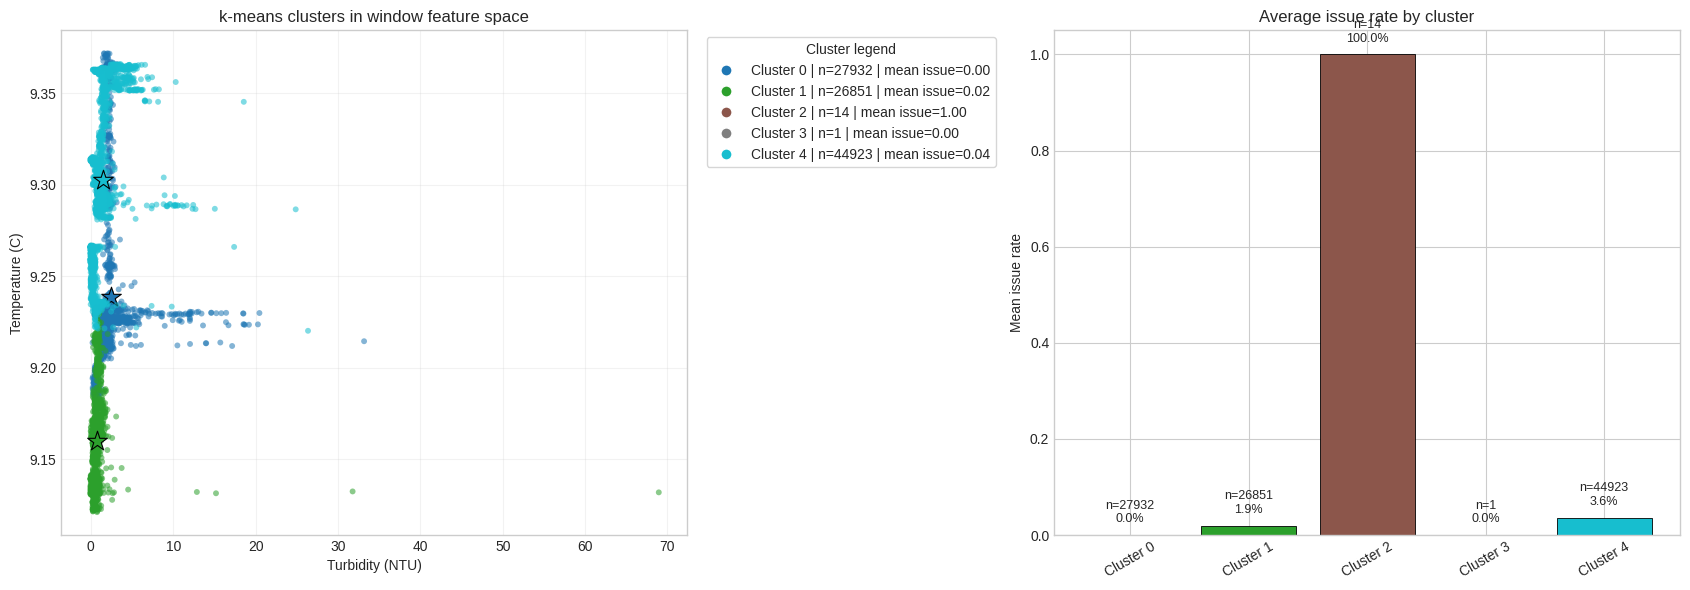

,window_start,window_end,source_file,cluster,issue_rate,distance_to_centroid
95136,2025-04-24 15:32:35.640000+00:00,2025-04-24 15:32:35.640000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,152.066
63647,2025-04-13 02:23:52.505000+00:00,2025-04-13 02:23:52.505000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,126.543
11525,2025-04-01 04:51:00.368000+00:00,2025-04-01 04:51:00.368000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,91.599
33590,2025-04-12 14:00:32.837000+00:00,2025-04-12 14:00:32.837000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,70.376
95138,2025-04-24 15:32:37.641000+00:00,2025-04-24 15:32:37.641000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,60.347
11527,2025-04-01 04:51:02.479000+00:00,2025-04-01 04:51:02.479000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,0,1.0,59.736
33588,2025-04-12 14:00:30.836000+00:00,2025-04-12 14:00:30.836000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,58.963
63649,2025-04-13 02:23:54.506000+00:00,2025-04-13 02:23:54.506000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,55.732
33587,2025-04-12 14:00:29.838000+00:00,2025-04-12 14:00:29.838000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,50.158
63646,2025-04-13 02:23:51.536000+00:00,2025-04-13 02:23:51.536000+00:00,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2,1.0,50.131


In [ ]:
# Plot a readable sample of windows so the scatter does not become an unreadable blob.
plot_window_df = evenly_spaced_take(window_df.sort_values("window_start"), 5000)
cluster_ids = sorted(cluster_summary.index.tolist())
cluster_colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_ids)))
cluster_palette = {cluster_id: cluster_colors[idx] for idx, cluster_id in enumerate(cluster_ids)}

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
cluster_centers = (
    plot_window_df.groupby("cluster")[[measurement_column_key, secondary_column_key]]
    #plot_window_df.groupby("cluster")[["Conductivity (S/m)_mean", "Temperature (C)_mean"]]
    .mean()
    .reindex(cluster_ids)
)

# Left panel: scatter in feature space with a real legend.
legend_handles = []
for cluster_id in cluster_ids:
    subset = plot_window_df[plot_window_df["cluster"] == cluster_id]
    axes[0].scatter(
        subset[measurement_column_key],
        subset[secondary_column_key],
        #subset["Conductivity (S/m)_mean"],
        #subset["Temperature (C)_mean"],
        s=18,
        alpha=0.55,
        color=cluster_palette[cluster_id],
        edgecolors="none",
    )
    axes[0].scatter(
        cluster_centers.loc[cluster_id, measurement_column_key],
        cluster_centers.loc[cluster_id, secondary_column_key],
        #cluster_centers.loc[cluster_id, "Conductivity (S/m)_mean"],
        #cluster_centers.loc[cluster_id, "Temperature (C)_mean"],
        s=220,
        marker="*",
        color=cluster_palette[cluster_id],
        edgecolors="black",
        linewidths=0.8,
    )
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=cluster_palette[cluster_id],
            markersize=8,
            label=(
                f"Cluster {cluster_id} | n={int(cluster_summary.loc[cluster_id, 'window_count'])} | "
                f"mean issue={cluster_summary.loc[cluster_id, 'mean_issue_rate']:.2f}"
            ),
        )
    )

axes[0].set_title("k-means clusters in window feature space")
axes[0].set_xlabel(measurement_column_str)
axes[0].set_ylabel(secondary_column_str)
#axes[0].set_xlabel("Conductivity mean (S/m)")
#axes[0].set_ylabel("Temperature mean (C)")
axes[0].grid(alpha=0.25)
axes[0].legend(handles=legend_handles, title="Cluster legend", loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)

# Right panel: bar chart is easier to read than a dense histogram for this audience.
bar_positions = np.arange(len(cluster_ids))
bar_values = [cluster_summary.loc[cluster_id, "mean_issue_rate"] for cluster_id in cluster_ids]
bar_colors = [cluster_palette[cluster_id] for cluster_id in cluster_ids]
axes[1].bar(bar_positions, bar_values, color=bar_colors, edgecolor="black", linewidth=0.6)
axes[1].set_xticks(bar_positions)
axes[1].set_xticklabels([f"Cluster {cluster_id}" for cluster_id in cluster_ids], rotation=30)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Mean issue rate")
axes[1].set_title("Average issue rate by cluster")
for idx, cluster_id in enumerate(cluster_ids):
    axes[1].text(
        idx,
        bar_values[idx] + 0.02,
        f"n={int(cluster_summary.loc[cluster_id, 'window_count'])}\n{bar_values[idx]:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

interesting_windows = window_df.sort_values(
    ["issue_rate", "distance_to_centroid"],
    ascending=[False, False],
).head(10)
interesting_windows = interesting_windows[["window_start", "window_end", "source_file", "cluster", "issue_rate", "distance_to_centroid"]].copy()
interesting_windows["source_file"] = interesting_windows["source_file"].str.replace(
    r"_\d{8}T\d{6}Z_\d{8}T\d{6}Z-NaN\.csv$",
    "",
    regex=True,
)
display(interesting_windows.round({"issue_rate": 3, "distance_to_centroid": 3}))


### Looking At Real Time-Series Windows From Each Cluster

The scatter plot shows where clusters sit in feature space, but it does not show what the underlying CTD behavior actually looked like.

The next plot closes that loop. For each cluster, we pick a representative window that sits close to its centroid, then:

- show a wider time-series context from the original row-level parquet,
- highlight the exact window used in k-means,
- mark the datapoints inside that highlighted window.

This makes it much easier to interpret clusters as real operating regimes rather than abstract colored dots.


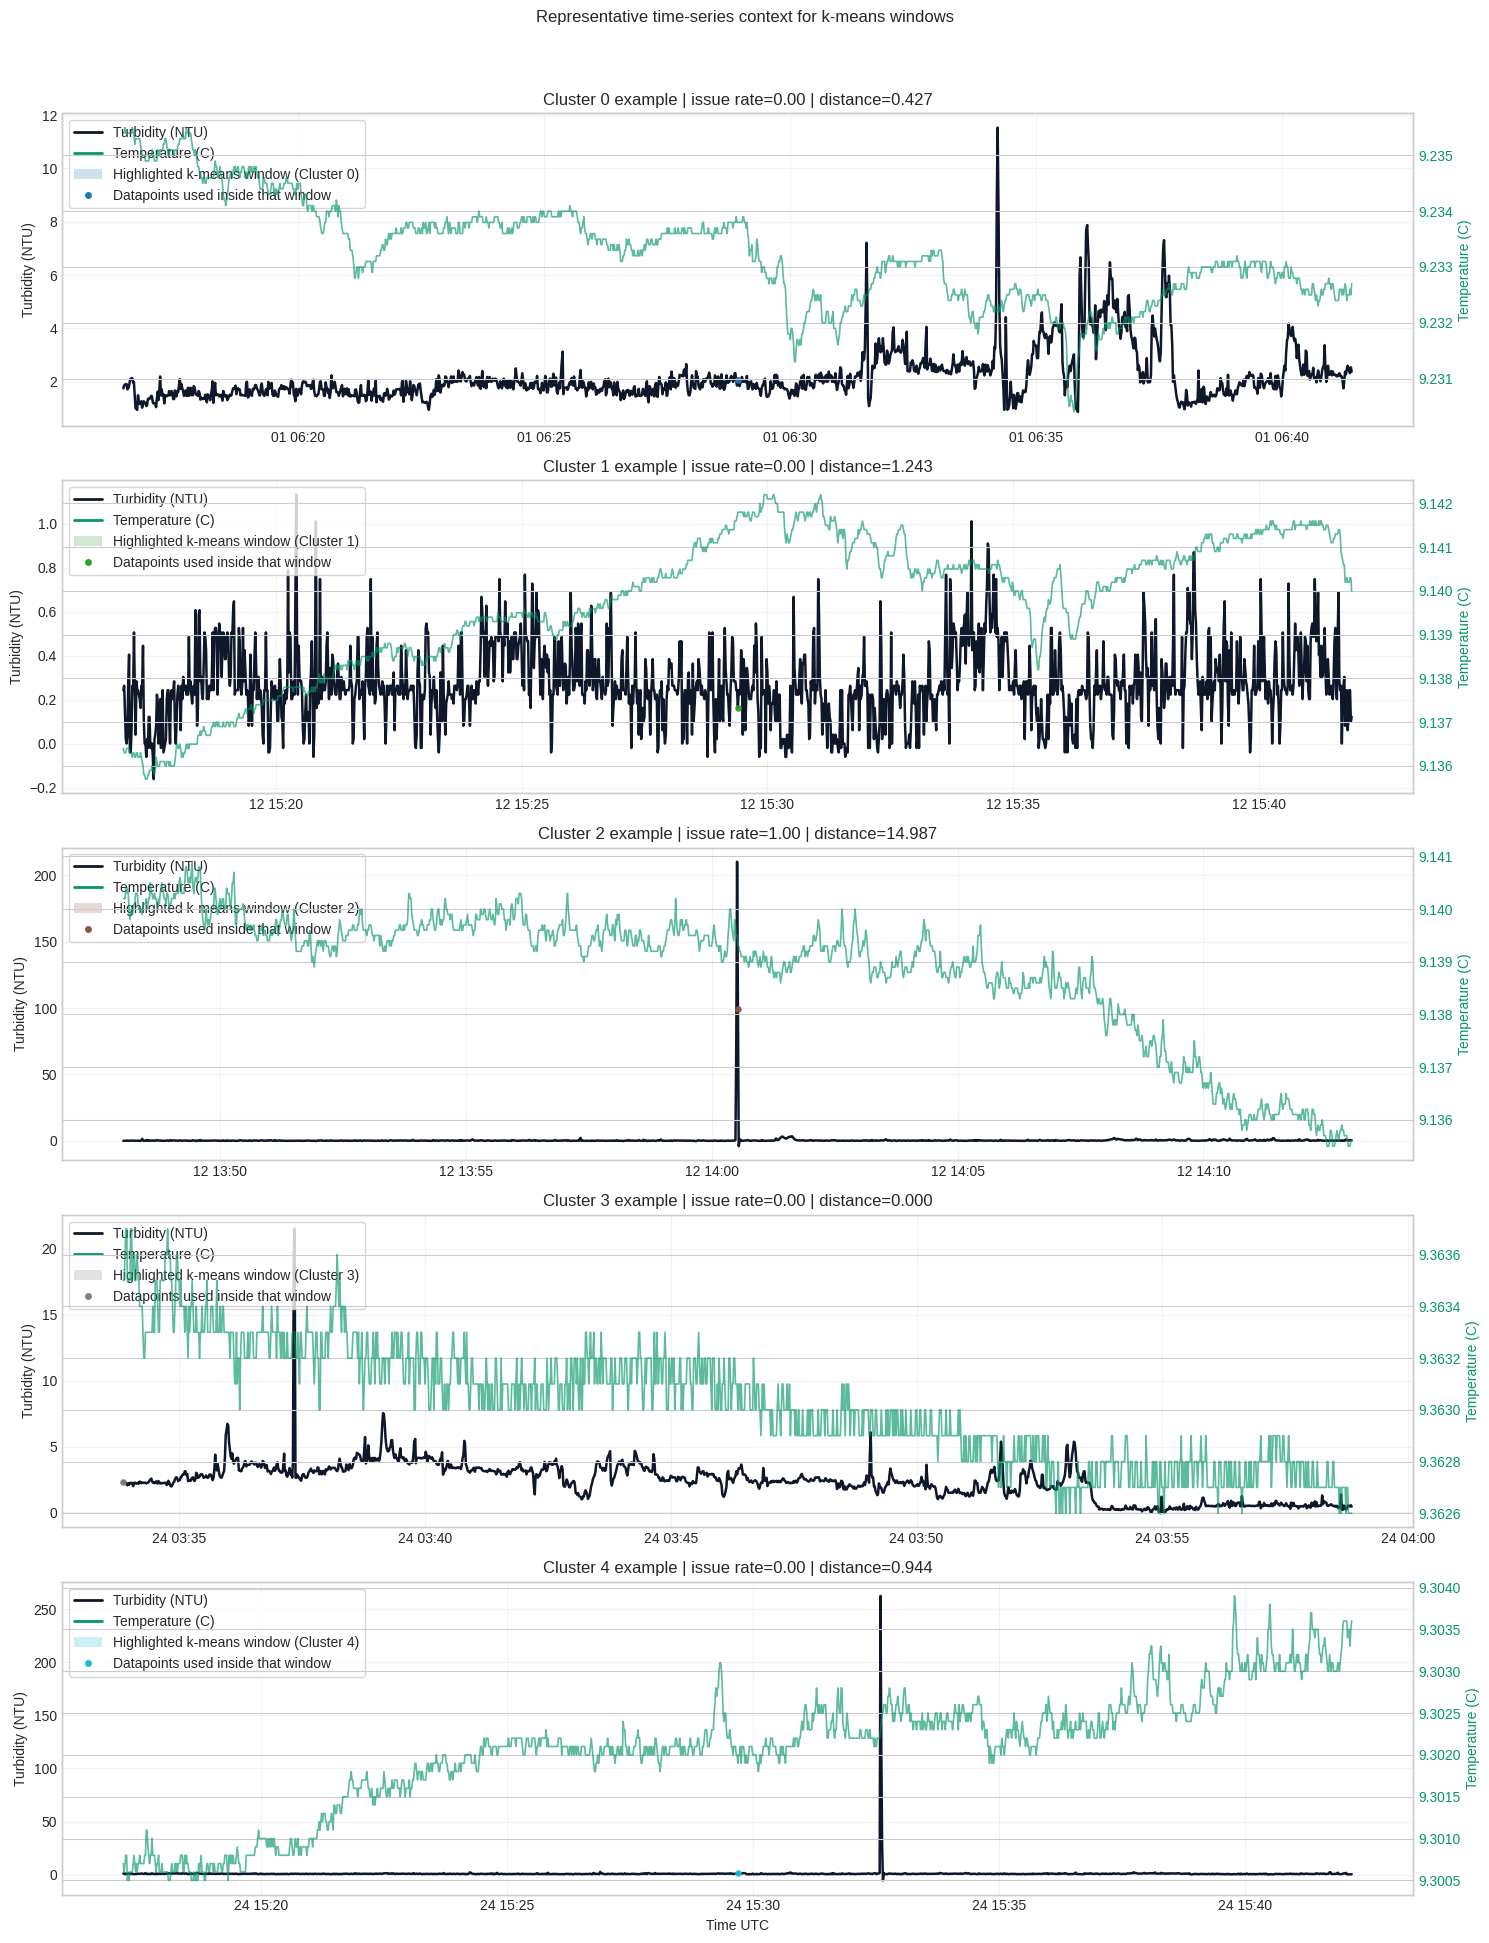

,cluster,source_file,window_start,window_end,issue_rate,distance_to_centroid,context_start,context_end,rows_in_highlighted_window
0,0,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2025-04-01 06:28:56.475000+00:00,2025-04-01 06:28:56.475000+00:00,0.0,0.427107,2025-04-01 06:16:26.524000+00:00,2025-04-01 06:41:25.440000+00:00,1
1,1,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2025-04-12 15:29:23.901000+00:00,2025-04-12 15:29:23.901000+00:00,0.0,1.243033,2025-04-12 15:16:53.895000+00:00,2025-04-12 15:41:52.933000+00:00,1
2,2,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2025-04-12 14:00:31.838000+00:00,2025-04-12 14:00:31.838000+00:00,1.0,14.987193,2025-04-12 13:48:01.825000+00:00,2025-04-12 14:13:00.845000+00:00,1
3,3,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2025-04-24 03:33:52.052000+00:00,2025-04-24 03:33:52.052000+00:00,0.0,0.000000,2025-04-24 03:33:52.052000+00:00,2025-04-24 03:58:51.027000+00:00,1
4,4,StraitofGeorgiaCentral_StraitofGeorgiaVENUSIns...,2025-04-24 15:29:41.638000+00:00,2025-04-24 15:29:41.638000+00:00,0.0,0.944101,2025-04-24 15:17:11.632000+00:00,2025-04-24 15:42:10.657000+00:00,1


In [ ]:
cluster_example_figure, cluster_example_windows = plot_cluster_window_examples(
    window_df,
    source_to_row_part=source_to_row_part,
    measurement_column=measurement_column_str,
    secondary_column=secondary_column_str,
    #measurement_column="Conductivity (S/m)",
    #secondary_column="Temperature (C)",
    examples_per_cluster=KMEANS_EXAMPLES_PER_CLUSTER,
    context_points=KMEANS_EXAMPLE_CONTEXT_POINTS,
    highlight_alpha=KMEANS_EXAMPLE_HIGHLIGHT_ALPHA,
)
plt.show()
display(cluster_example_windows)


### Date-Range Demo: See Which Clusters Appear in a Specific Interval

k-means does not predict QC flags directly. Instead, it groups short windows with similar summary behavior.

This demo lets us ask: **what kinds of windows show up inside one selected time range, and how do their issue rates differ?**


In [26]:
KMEANS_RANGE_START = None
KMEANS_RANGE_END = None
KMEANS_AUTO_SELECT_TEST_RANGE = True
KMEANS_MAX_POINTS_TO_PLOT = 800

print(
    {
        "KMEANS_RANGE_START": KMEANS_RANGE_START,
        "KMEANS_RANGE_END": KMEANS_RANGE_END,
        "KMEANS_AUTO_SELECT_TEST_RANGE": KMEANS_AUTO_SELECT_TEST_RANGE,
        "KMEANS_MAX_POINTS_TO_PLOT": KMEANS_MAX_POINTS_TO_PLOT,
    }
)


{'KMEANS_RANGE_START': None, 'KMEANS_RANGE_END': None, 'KMEANS_AUTO_SELECT_TEST_RANGE': True, 'KMEANS_MAX_POINTS_TO_PLOT': 800}


{'selection_mode': 'auto', 'selected_priority_flag': 4, 'interval_origin': 'test', 'range_start': '2025-04-24T16:42:58.733000+00:00', 'range_end': '2025-04-24T17:02:22.742000+00:00', 'row_points_in_interval': 1165, 'window_count_in_interval': 800}


,window_count,mean_issue_rate,max_issue_rate
cluster,,,
4,800,0.102,1.0


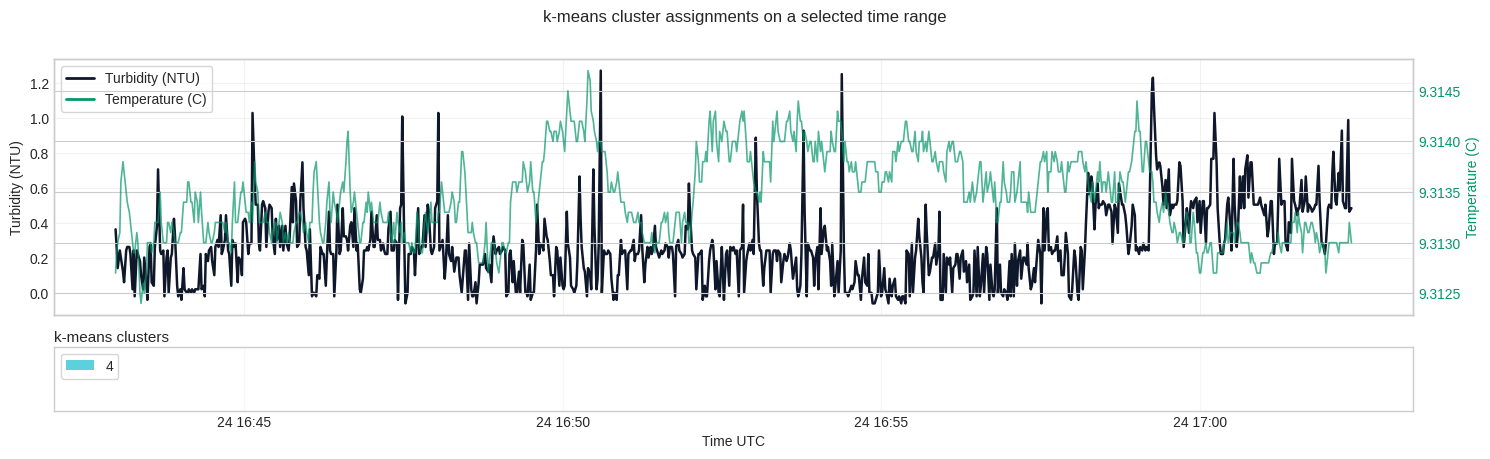

In [ ]:
kmeans_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=KMEANS_RANGE_START,
    end=KMEANS_RANGE_END,
    auto_select=KMEANS_AUTO_SELECT_TEST_RANGE,
    max_points=KMEANS_MAX_POINTS_TO_PLOT,
)

kmeans_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=kmeans_range_selection["start"],
    end=kmeans_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)
kmeans_interval_windows = window_df[
    (window_df["window_start"] <= kmeans_range_selection["end"])
    & (window_df["window_end"] >= kmeans_range_selection["start"])
].copy()

if kmeans_interval_rows.empty or kmeans_interval_windows.empty:
    print("No overlapping k-means windows were found in the requested range.")
else:
    kmeans_interval_origin = infer_interval_origin(
        kmeans_range_selection["start"],
        kmeans_range_selection["end"],
        {"train": train_df, "validation": valid_df, "test": test_df},
    )
    kmeans_interval_intervals = merge_adjacent_intervals(
        kmeans_interval_windows.rename(
            columns={"window_start": "start", "window_end": "end", "cluster": "label"}
        )[["start", "end", "label"]]
    )
    kmeans_cluster_counts = (
        kmeans_interval_windows.groupby("cluster")
        .agg(
            window_count=("cluster", "size"),
            mean_issue_rate=("issue_rate", "mean"),
            max_issue_rate=("issue_rate", "max"),
        )
        .sort_index()
    )

    print(
        {
            "selection_mode": kmeans_range_selection["selection_mode"],
            "selected_priority_flag": kmeans_range_selection["selected_label"],
            "interval_origin": kmeans_interval_origin,
            "range_start": kmeans_range_selection["start"].isoformat(),
            "range_end": kmeans_range_selection["end"].isoformat(),
            "row_points_in_interval": int(len(kmeans_interval_rows)),
            "window_count_in_interval": int(len(kmeans_interval_windows)),
        }
    )
    display(kmeans_cluster_counts.round(3))

    kmeans_demo_figure = plot_time_series_with_bands(
        kmeans_interval_rows,
        band_specs=[
            {
                "title": "k-means clusters",
                "intervals": kmeans_interval_intervals,
                "palette": cluster_palette,
            }
        ],
        measurement_column=measurement_column_str,
        secondary_column = secondary_column_str,
        #measurement_column="Conductivity (S/m)",
        #secondary_column="Temperature (C)",
        max_points=KMEANS_MAX_POINTS_TO_PLOT,
        title="k-means cluster assignments on a selected time range",
    )
    plt.show()


        ### Reflection Questions: k-means

        1. Do these cluster spans look like real operating regimes, or do some clusters still seem hard to interpret physically?
2. If you changed `n_clusters`, which regions in this interval do you expect would split apart or merge together?
3. How closely do the cluster spans line up with QC-flag changes, and what does that say about the usefulness of unsupervised learning here?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


## Part 6 — 1D CNN

Now we keep short stretches of signal together as one training example and see how a sequence model behaves when it learns local time patterns directly.


### Sequential Model: 1D CNN

A **convolutional neural network (CNN)** applies small learnable filters across an ordered signal. For images that order is two-dimensional. In this notebook, the order is **time**.

The key idea is:

1. a short filter looks at a local pattern,
2. the same filter slides across the whole sequence,
3. later layers combine those detected patterns into a final prediction.

For this CTD task, a 1D CNN can learn patterns such as:

- sudden spikes or drops,
- flat segments,
- repeated local shapes across several sensor channels.

Why this is useful here:

- Random Forest treats each row mostly as a tabular snapshot,
- CNN keeps a short stretch of signal together as one example,
- the training loop also gives us a chance to teach batching, validation checkpoints, and early stopping.

The CNN section runs by default in this notebook and follows standard training practice:

- train / validation / test split,
- class-aware loss weighting,
- best-checkpoint saving based on validation F1,
- early stopping,
- mini-batch training through `DataLoader`,
- pinned-memory and multi-worker loading when the local machine supports it.

Useful references: [PyTorch tutorial on defining neural networks](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial), [PyTorch DataLoader docs](https://pytorch.org/docs/stable/data.html), [PyTorch performance tuning guide](https://pytorch.org/tutorials/recipes/recipes/tuning_guide.html)


![Convolutional network diagram](../assets/session1/convolutional_network.png)

Diagram idea: small filters slide across the input, produce feature maps, and later layers combine those maps into a final prediction.

In this notebook the same logic is applied to **1D time windows** rather than 2D images.

Image credit: Aphex34, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Convolutional Network.png](https://commons.wikimedia.org/wiki/File:Convolutional_Network.png)


### 🎛️ CNN Settings

These settings control the baseline 1D CNN and its training loop.

Model-shape variables:

- `window_size`: number of time steps in each training window.
- `conv_channels`: number of filters in each convolution layer.
- `dropout`: dropout probability used for regularization.
- `label_reduction`: how row-level labels become one window label. Here we use `"worst"`.

Optimization variables:

- `epochs`: maximum number of passes through the training data.
- `batch_size`: number of windows per optimization step.
- `learning_rate`: optimizer step size.
- `weight_decay`: L2-style regularization for the optimizer.
- `patience` and `min_delta`: early-stopping controls.
- `lr_decay_factor` and `lr_patience`: learning-rate scheduler controls.
- `gradient_clip_norm`: cap on gradient size to stabilize training.

DataLoader variables:

- `num_workers`: worker processes for loading batches.
- `pin_memory`: can speed up host-to-GPU transfer.
- `persistent_workers`: keeps workers alive between epochs.
- `prefetch_factor`: how many batches each worker prepares ahead of time.


In [37]:
CNN_CONFIG = {
    "window_size": 128,
    "epochs": 10,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 3,
    "min_delta": 0.001,
    "dropout": 0.2,
    "lr_decay_factor": 0.5,
    "lr_patience": 1,
    "gradient_clip_norm": 1.0,
    "conv_channels": [32, 64],
    "label_reduction": "worst",
}

CNN_LOADER_CONFIG = {
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
}

display(pd.Series(CNN_CONFIG, name="value").rename_axis("cnn_parameter").to_frame())
display(pd.Series(CNN_LOADER_CONFIG, name="value").rename_axis("loader_parameter").to_frame())


,value
cnn_parameter,
window_size,128
epochs,10
batch_size,128
learning_rate,0.001
weight_decay,0.0001
patience,3
min_delta,0.001
dropout,0.2
lr_decay_factor,0.5


,value
loader_parameter,
num_workers,4
pin_memory,True
persistent_workers,True
prefetch_factor,2


### CNN Step 1: Turn Rows into Windows

A CNN expects a fixed-size tensor, not an arbitrary-length table.

In this step we:

- collect the measurement columns we want to model,
- group consecutive rows into fixed windows,
- reduce many row-level QC flags into one window label,
- split the windows in time order into train, validation, and test groups,
- normalize each sensor channel using only the training split.

This is a good place to pause in a live session and ask: what information do we lose when we compress several row labels into one window label?


In [38]:
if not RUN_CNN_APPENDIX:
    print("CNN appendix skipped. Set RUN_CNN_APPENDIX = True in the configuration cell to enable it.")
    CNN_READY = False
else:
    try:
        import torch
        from torch import nn
        from torch.utils.data import DataLoader, TensorDataset
        CNN_READY = True
        print({
            "torch": torch.__version__,
            "cuda_available": torch.cuda.is_available(),
            "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        })
    except ImportError as exc:
        CNN_READY = False
        print("PyTorch is not installed in this environment.")
        raise SystemExit(exc)


{'torch': '2.6.0', 'cuda_available': True, 'device_name': 'NVIDIA H100 80GB HBM3 MIG 1g.10gb'}


In [39]:
if not CNN_READY:
    CNN_RUN = False
    print("CNN training cell skipped.")
else:
    # Build fixed windows from the row-level sample.
    WINDOW_SIZE = CNN_CONFIG["window_size"]
    cnn_df = model_df[measurement_columns + ["model_target"]].copy().dropna().reset_index(drop=True)
    usable_rows = (len(cnn_df) // WINDOW_SIZE) * WINDOW_SIZE
    cnn_df = cnn_df.iloc[:usable_rows]

    raw_sequences = cnn_df[measurement_columns].to_numpy(dtype=np.float32).reshape(
        -1,
        WINDOW_SIZE,
        len(measurement_columns),
    )
    raw_window_targets = cnn_df["model_target"].to_numpy().reshape(-1, WINDOW_SIZE)

    if task_mode == "multiclass":
        window_targets = np.array(
            [reduce_window_target(row, mode=CNN_CONFIG["label_reduction"]) for row in raw_window_targets],
            dtype=np.int64,
        )
        class_labels = sorted(np.unique(window_targets).tolist())
        label_to_index = {label: index for index, label in enumerate(class_labels)}
        encoded_targets = np.array([label_to_index[label] for label in window_targets], dtype=np.int64)
    else:
        class_labels = [0, 1]
        encoded_targets = raw_window_targets.max(axis=1).astype(np.float32)

    # Move to channel-first layout expected by Conv1D.
    sequences = np.transpose(raw_sequences, (0, 2, 1))

    # Keep the split contiguous in time so validation and test remain realistic.
    train_end = int(len(sequences) * TRAIN_FRACTION)
    valid_end = int(len(sequences) * (TRAIN_FRACTION + VALIDATION_FRACTION))
    X_train = sequences[:train_end]
    X_valid = sequences[train_end:valid_end]
    X_test = sequences[valid_end:]
    y_train = encoded_targets[:train_end]
    y_valid = encoded_targets[train_end:valid_end]
    y_test = encoded_targets[valid_end:]

    # Normalize each sensor channel using only the training split.
    channel_mean = X_train.mean(axis=(0, 2), keepdims=True)
    channel_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    X_train = (X_train - channel_mean) / channel_std
    X_valid = (X_valid - channel_mean) / channel_std
    X_test = (X_test - channel_mean) / channel_std

    CNN_RUN = True
    print(
        {
            "windows_total": int(len(sequences)),
            "train_windows": int(len(X_train)),
            "validation_windows": int(len(X_valid)),
            "test_windows": int(len(X_test)),
            "window_size": int(WINDOW_SIZE),
            "channels": int(len(measurement_columns)),
        }
    )


{'windows_total': 779, 'train_windows': 545, 'validation_windows': 117, 'test_windows': 117, 'window_size': 128, 'channels': 12}


### CNN Step 2: Build the Model and the DataLoaders

Here we create four pieces:

- the neural network itself,
- the loss function,
- the optimizer and learning-rate scheduler,
- the `DataLoader` objects that stream mini-batches during training.

Notice that the `DataLoader` keeps the full dataset in CPU memory and feeds the GPU one batch at a time. That is usually much more efficient than trying to move every window onto the GPU all at once.


In [40]:
if not CNN_RUN:
    print("CNN model setup skipped.")
else:
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True

    class TinyQCNet(nn.Module):
        def __init__(self, channels: int, output_dim: int) -> None:
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(channels, CNN_CONFIG["conv_channels"][0], kernel_size=7, padding=3),
                nn.ReLU(),
                nn.Conv1d(CNN_CONFIG["conv_channels"][0], CNN_CONFIG["conv_channels"][1], kernel_size=5, padding=2),
                nn.ReLU(),
                nn.Dropout(CNN_CONFIG["dropout"]),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten(),
                nn.Linear(CNN_CONFIG["conv_channels"][1], output_dim),
            )

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.net(x)

    if task_mode == "multiclass":
        train_targets_tensor = torch.from_numpy(y_train).long()
        valid_targets_tensor = torch.from_numpy(y_valid).long()
        test_targets_tensor = torch.from_numpy(y_test).long()
        class_counts = np.bincount(y_train, minlength=len(class_labels)).clip(min=1)
        class_weights = len(y_train) / (len(class_counts) * class_counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
        output_dim = len(class_labels)
    else:
        train_targets_tensor = torch.from_numpy(y_train.astype(np.float32))
        valid_targets_tensor = torch.from_numpy(y_valid.astype(np.float32))
        test_targets_tensor = torch.from_numpy(y_test.astype(np.float32))
        positive_count = max(float(y_train.sum()), 1.0)
        negative_count = max(float(len(y_train) - y_train.sum()), 1.0)
        pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32, device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        output_dim = 1

    train_dataset = TensorDataset(torch.from_numpy(X_train).float(), train_targets_tensor)
    valid_dataset = TensorDataset(torch.from_numpy(X_valid).float(), valid_targets_tensor)
    test_dataset = TensorDataset(torch.from_numpy(X_test).float(), test_targets_tensor)

    loader_kwargs = {}
    num_workers = int(CNN_LOADER_CONFIG["num_workers"])
    if num_workers > 0:
        loader_kwargs["num_workers"] = num_workers
        loader_kwargs["persistent_workers"] = bool(CNN_LOADER_CONFIG["persistent_workers"])
        loader_kwargs["prefetch_factor"] = int(CNN_LOADER_CONFIG["prefetch_factor"])
    if CNN_LOADER_CONFIG["pin_memory"]:
        loader_kwargs["pin_memory"] = True
    use_non_blocking = bool(loader_kwargs.get("pin_memory", False) and device.type == "cuda")

    train_loader = DataLoader(
        train_dataset,
        batch_size=CNN_CONFIG["batch_size"],
        shuffle=True,
        **loader_kwargs,
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=CNN_CONFIG["batch_size"],
        shuffle=False,
        **loader_kwargs,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=CNN_CONFIG["batch_size"],
        shuffle=False,
        **loader_kwargs,
    )

    model = TinyQCNet(channels=len(measurement_columns), output_dim=output_dim).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CNN_CONFIG["learning_rate"],
        weight_decay=CNN_CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=CNN_CONFIG["lr_decay_factor"],
        patience=CNN_CONFIG["lr_patience"],
    )

    best_metric = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []
    best_state = None

    def run_epoch(loader, training: bool) -> tuple[float, np.ndarray, np.ndarray]:
        model.train(training)
        total_loss = 0.0
        predictions = []
        targets = []
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=use_non_blocking)
            batch_y = batch_y.to(device, non_blocking=use_non_blocking)
            with torch.set_grad_enabled(training):
                logits = model(batch_x)
                if task_mode == "multiclass":
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = logits.argmax(dim=1)
                else:
                    logits = logits.squeeze(-1)
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = (torch.sigmoid(logits) >= 0.5).long()
                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    if CNN_CONFIG["gradient_clip_norm"]:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), CNN_CONFIG["gradient_clip_norm"])
                    optimizer.step()
            total_loss += float(loss.item()) * len(batch_x)
            predictions.append(batch_predictions.detach().cpu().numpy())
            targets.append(batch_y.detach().cpu().numpy())
        predictions_array = np.concatenate(predictions) if predictions else np.array([])
        targets_array = np.concatenate(targets) if targets else np.array([])
        average_loss = total_loss / max(len(loader.dataset), 1)
        return average_loss, predictions_array, targets_array

    print(
        {
            "device": str(device),
            "train_batches": len(train_loader),
            "validation_batches": len(valid_loader),
            "test_batches": len(test_loader),
            "loader_config": CNN_LOADER_CONFIG,
        }
    )


/project/6062898/shared/daqathon-ml-venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


{'device': 'cuda', 'train_batches': 5, 'validation_batches': 1, 'test_batches': 1, 'loader_config': {'num_workers': 4, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 2}}


### CNN Step 3: Train with Validation Monitoring

This cell runs the optimization loop.

We are following standard training practice:

- train on the training split,
- score the model on the validation split after each epoch,
- save the best checkpoint seen so far,
- stop early if the validation metric stops improving.

Watch the printed validation F1 as the run progresses. That is the signal we use to decide which checkpoint is best.


In [41]:
if not CNN_RUN:
    print("CNN fit skipped.")
else:
    for epoch in range(1, CNN_CONFIG["epochs"] + 1):
        train_loss, _, _ = run_epoch(train_loader, training=True)
        valid_loss, valid_preds, valid_targets = run_epoch(valid_loader, training=False)
        valid_f1 = f1_score(valid_targets, valid_preds, average=report_average(task_mode), zero_division=0)
        scheduler.step(valid_f1)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "valid_f1": valid_f1,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )
        print(
            f"Epoch {epoch:>2} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | valid_f1={valid_f1:.4f}"
        )

        if valid_f1 > best_metric + CNN_CONFIG["min_delta"]:
            best_metric = valid_f1
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state_dict": best_state,
                    "task_mode": task_mode,
                    "class_labels": class_labels,
                    "feature_columns": measurement_columns,
                    "window_size": WINDOW_SIZE,
                    "config": {**CNN_CONFIG, **CNN_LOADER_CONFIG},
                },
                CNN_MODEL_PATH,
            )
        else:
            patience_counter += 1
            if patience_counter >= CNN_CONFIG["patience"]:
                print(f"Early stopping triggered at epoch {epoch}")
                break


/project/6062898/shared/daqathon-ml-venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


: 

### CNN Step 4: Reload the Best Checkpoint and Evaluate

Training loss alone is not enough. In this final step we:

- reload the weights that gave the best validation F1,
- run the held-out test split once,
- inspect the classification report and confusion matrix.

This keeps the evaluation honest and makes it clear that the validation set guided model selection, while the test set is reserved for final reporting.


In [ ]:
if not CNN_RUN:
    print("CNN evaluation skipped.")
else:
    if best_state is None:
        raise RuntimeError("CNN training did not produce a valid checkpoint")

    model.load_state_dict(best_state)
    test_loss, test_preds, test_targets = run_epoch(test_loader, training=False)

    print(pd.DataFrame(history).tail())
    print(
        {
            "windows": len(train_dataset) + len(valid_dataset) + len(test_dataset),
            "device": str(device),
            "best_validation_f1": float(best_metric),
            "best_epoch": best_epoch,
            "test_loss": float(test_loss),
            "saved_model": str(CNN_MODEL_PATH),
            "loader_config": CNN_LOADER_CONFIG,
        }
    )

    if task_mode == "multiclass":
        report_labels = list(range(len(class_labels)))
        report_names = [str(label) for label in class_labels]
    else:
        report_labels = [0, 1]
        report_names = ["0", "1"]

    print(
        classification_report(
            test_targets,
            test_preds,
            labels=report_labels,
            target_names=report_names,
            zero_division=0,
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    history_frame = pd.DataFrame(history)
    axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="train")
    axes[0].plot(history_frame["epoch"], history_frame["valid_loss"], label="validation")
    axes[0].set_title("CNN loss history")
    axes[0].legend()
    ConfusionMatrixDisplay.from_predictions(
        test_targets,
        test_preds,
        labels=report_labels,
        display_labels=report_names,
        normalize="true",
        xticks_rotation=45,
        ax=axes[1],
    )
    axes[1].set_title("CNN test confusion matrix")
    plt.tight_layout()
    plt.show()


### Date-Range Demo: See CNN Window Predictions on a Specific Interval

The baseline CNN predicts **one label per window**, not one label per timestamp.

That means the plot below shows window-level spans for the true and predicted labels across the selected interval.


In [ ]:
CNN_RANGE_START = None
CNN_RANGE_END = None
CNN_AUTO_SELECT_TEST_RANGE = True
CNN_MAX_POINTS_TO_PLOT = 1024

print(
    {
        "CNN_RANGE_START": CNN_RANGE_START,
        "CNN_RANGE_END": CNN_RANGE_END,
        "CNN_AUTO_SELECT_TEST_RANGE": CNN_AUTO_SELECT_TEST_RANGE,
        "CNN_MAX_POINTS_TO_PLOT": CNN_MAX_POINTS_TO_PLOT,
    }
)


In [ ]:
cnn_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=CNN_RANGE_START,
    end=CNN_RANGE_END,
    auto_select=CNN_AUTO_SELECT_TEST_RANGE,
    max_points=CNN_MAX_POINTS_TO_PLOT,
)

cnn_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=cnn_range_selection["start"],
    end=cnn_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)

if cnn_interval_rows.empty:
    print("No row-level data was found in the requested CNN range.")
else:
    cnn_interval_model_df, _, _ = build_model_frame(
        cnn_interval_rows,
        target_flag=TARGET_FLAG,
        task_mode=task_mode,
        model_row_limit=None,
    )
    cnn_interval_model_df = cnn_interval_model_df[
        (cnn_interval_model_df["Time UTC"] >= cnn_range_selection["start"])
        & (cnn_interval_model_df["Time UTC"] <= cnn_range_selection["end"])
    ].reset_index(drop=True)

    cnn_interval_bundle = build_window_classification_interval_data(
        cnn_interval_model_df,
        feature_columns=measurement_columns,
        target_column="model_target",
        task_mode=task_mode,
        window_size=CNN_CONFIG["window_size"],
        label_reduction=CNN_CONFIG["label_reduction"],
    )

    if cnn_interval_bundle["window_frame"].empty:
        print("The selected CNN range is shorter than one full window after preprocessing, so the window-level demo is skipped.")
    else:
        cnn_predicted_labels = predict_cnn_window_model(
            model,
            cnn_interval_bundle["raw_sequences"],
            task_mode=task_mode,
            class_labels=class_labels,
            device=str(device),
            channel_mean=channel_mean,
            channel_std=channel_std,
            batch_size=CNN_CONFIG["batch_size"],
        )
        cnn_window_frame = cnn_interval_bundle["window_frame"].copy()
        cnn_window_frame["predicted_label"] = cnn_predicted_labels
        cnn_interval_origin = infer_interval_origin(
            cnn_range_selection["start"],
            cnn_range_selection["end"],
            {"train": train_df, "validation": valid_df, "test": test_df},
        )
        cnn_interval_metrics = compute_interval_classification_metrics(
            cnn_window_frame["true_label"],
            cnn_window_frame["predicted_label"],
            labels=class_labels,
            average=report_average(task_mode),
            target_names=[str(label) for label in class_labels],
        )
        cnn_plot_palette = DEFAULT_FLAG_PALETTE if task_mode == "multiclass" else {0: "#1f77b4", 1: "#d62728"}
        cnn_true_intervals = merge_adjacent_intervals(
            cnn_window_frame.rename(columns={"window_start": "start", "window_end": "end", "true_label": "label"})[
                ["start", "end", "label"]
            ]
        )
        cnn_pred_intervals = merge_adjacent_intervals(
            cnn_window_frame.rename(columns={"window_start": "start", "window_end": "end", "predicted_label": "label"})[
                ["start", "end", "label"]
            ]
        )

        print(
            {
                "selection_mode": cnn_range_selection["selection_mode"],
                "selected_priority_flag": cnn_range_selection["selected_label"],
                "interval_origin": cnn_interval_origin,
                "range_start": cnn_range_selection["start"].isoformat(),
                "range_end": cnn_range_selection["end"].isoformat(),
                "window_count_in_interval": int(len(cnn_window_frame)),
                "interval_f1": cnn_interval_metrics["f1"],
            }
        )
        print(cnn_interval_metrics["report_text"])
        display(
            pd.DataFrame(
                {
                    "true_count": cnn_window_frame["true_label"].value_counts().sort_index(),
                    "predicted_count": cnn_window_frame["predicted_label"].value_counts().sort_index(),
                }
            ).fillna(0).astype(int)
        )

        cnn_demo_figure = plot_time_series_with_bands(
            cnn_interval_model_df,
            band_specs=[
                {"title": "True window label", "intervals": cnn_true_intervals, "palette": cnn_plot_palette},
                {"title": "CNN window prediction", "intervals": cnn_pred_intervals, "palette": cnn_plot_palette},
            ],
            measurement_column=measurement_column_str,
            secondary_column=secondary_column_str,
            #measurement_column="Conductivity (S/m)",
            #secondary_column="Temperature (C)",
            max_points=CNN_MAX_POINTS_TO_PLOT,
            title="Baseline CNN window predictions on a selected time range",
        )
        plt.show()

        cnn_cm_fig, cnn_cm_ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=cnn_interval_metrics["confusion_matrix"],
            display_labels=cnn_interval_metrics["display_labels"],
        ).plot(ax=cnn_cm_ax, cmap="Blues", colorbar=False)
        cnn_cm_ax.set_title("CNN confusion matrix on the selected range")
        plt.tight_layout()
        plt.show()


        ### Reflection Questions: Baseline CNN

        1. How much information do we lose when we compress a whole window into one label, and can you see that loss in this interval?
2. If this window-level prediction is too coarse, would you change the window size, the label reduction rule, or the model architecture first?
3. Do the mistakes here look more like a data-representation problem or a training-hyperparameter problem?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


## Part 7 — Transformer

The transformer keeps the same supervised task but changes how the model uses context inside each sequence window.


### Sequential Model: Small Transformer Encoder

A **transformer** is another sequence model, but instead of mainly asking "what local pattern is near me?", it asks "which other positions in this window should I pay attention to right now?"

A beginner-friendly way to think about it is:

- a CNN is like a sliding magnifying glass that looks for local shapes,
- a transformer is more like a smart lookup step where each time point can compare itself to every other time point in the same window,
- the model learns which other positions matter most for making a good representation.

That ability is important when the meaning of one measurement depends on context that may be far away in the same sequence.

For this notebook we train a small **encoder-only transformer** for classification. We are not generating text, so we only use the encoder side of the original architecture plus a classifier on top.

Why this matters for our CTD data:

- CNN is strongest when short local patterns matter,
- a transformer can compare events across more positions in the same window,
- that gives us one concrete example of a longer-context sequence model.

Suggested beginner-friendly reading if you want more intuition after the notebook:

- [Google Research: Transformer, a novel neural network architecture for language understanding](https://research.google/blog/transformer-a-novel-neural-network-architecture-for-language-understanding/)
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)


![Transformer model architecture](../assets/session1/transformer_model_architecture.png)

This is the big-picture map. The original transformer has:

- an **encoder stack** on the left,
- a **decoder stack** on the right.

In this notebook we only use the **encoder stack** and attach a classifier on top. So when you look at the rest of the section, focus mostly on the left half of this picture rather than trying to memorize the whole diagram.

Image credit: Arz, Wikimedia Commons, CC BY-SA 4.0. Source: [File:The-Transformer-model-architecture.png](https://commons.wikimedia.org/wiki/File:The-Transformer-model-architecture.png)


![Detailed encoder self-attention diagram](../assets/session1/transformer_encoder_self_attention_detailed.png)

This picture zooms in on the core idea of **self-attention**.

You do not need to memorize every symbol here. The important story is:

- each position creates a few learned views of itself,
- those views are compared against other positions,
- the model turns those comparisons into attention weights,
- then it blends information from the whole window into a new representation.

In plain language: a timestep can decide which other timesteps are worth listening to.

Image credit: dvgodoy, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Encoder self-attention, detailed diagram.png](https://commons.wikimedia.org/wiki/File:Encoder_self-attention,_detailed_diagram.png)


![Positional encoding heatmap](../assets/session1/transformer_positional_encoding.png)

One natural question is: if attention can compare all positions to all other positions, how does the model know **where** each timestep sits in the sequence?

That is the job of **positional encoding**.

This heatmap shows that each position gets its own pattern added to the input representation. That gives the transformer access to order information, so it can tell the difference between "this happened early in the window" and "this happened later".

Image credit: Mdbartosz, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Positional encoding.png](https://commons.wikimedia.org/wiki/File:Positional_encoding.png)


### Transformer Settings

Main model variables:

- `window_size`: number of time steps in each window.
- `d_model`: internal embedding size for each position.
- `nhead`: number of attention heads. This must divide `d_model`.
- `num_layers`: number of stacked encoder layers.
- `dim_feedforward`: hidden size of the feed-forward sublayer inside each encoder block.
- `dropout`: dropout used inside the model.
- `pooling`: how we reduce the sequence to one vector for classification. We use `"mean"` here, but `"last"` is another simple option.
- `label_reduction`: how row-level labels become one window label.

Training variables:

- `epochs`, `batch_size`, `learning_rate`, `weight_decay`
- `patience`, `min_delta`
- `lr_decay_factor`, `lr_patience`
- `gradient_clip_norm`

Practical note:

- larger `window_size`, `d_model`, or `num_layers` can improve context capacity,
- but they also increase memory use and training time.

A simple mental model for the main knobs:

- `window_size` controls how much time context the model can see,
- `d_model` controls how much representational space each timestep gets,
- `nhead` controls how many different attention patterns the model can learn in parallel,
- `num_layers` controls how many times the sequence is reprocessed with attention.


In [ ]:
TRANSFORMER_CONFIG = {
    "window_size": 128,
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.2,
    "pooling": "mean",
    "label_reduction": "worst",
    "epochs": 8,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 3,
    "min_delta": 0.001,
    "lr_decay_factor": 0.5,
    "lr_patience": 1,
    "gradient_clip_norm": 1.0,
}

TRANSFORMER_LOADER_CONFIG = {
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
}

display(pd.Series(TRANSFORMER_CONFIG, name="value").rename_axis("transformer_parameter").to_frame())
display(pd.Series(TRANSFORMER_LOADER_CONFIG, name="value").rename_axis("loader_parameter").to_frame())


### Transformer Step 1: Prepare Windowed Sequence Data

The transformer uses the same row sample as the CNN, but it keeps the sequence in its original time-major layout.

In other words:

- CNN sees `[batch, channels, time]`,
- transformer sees `[batch, time, features]`.

That makes this step a nice comparison point between two sequence models trained on the same CTD problem.


In [ ]:
if not CNN_READY:
    TRANSFORMER_RUN = False
    print("Transformer training cell skipped.")
else:
    transformer_window_size = TRANSFORMER_CONFIG["window_size"]
    transformer_df = model_df[measurement_columns + ["model_target"]].copy().dropna().reset_index(drop=True)
    usable_rows = (len(transformer_df) // transformer_window_size) * transformer_window_size
    transformer_df = transformer_df.iloc[:usable_rows]

    raw_sequences = transformer_df[measurement_columns].to_numpy(dtype=np.float32).reshape(
        -1,
        transformer_window_size,
        len(measurement_columns),
    )
    raw_window_targets = transformer_df["model_target"].to_numpy().reshape(-1, transformer_window_size)

    if task_mode == "multiclass":
        window_targets = np.array(
            [reduce_window_target(row, mode=TRANSFORMER_CONFIG["label_reduction"]) for row in raw_window_targets],
            dtype=np.int64,
        )
        transformer_class_labels = sorted(np.unique(window_targets).tolist())
        label_to_index = {label: index for index, label in enumerate(transformer_class_labels)}
        encoded_targets = np.array([label_to_index[label] for label in window_targets], dtype=np.int64)
    else:
        transformer_class_labels = [0, 1]
        encoded_targets = raw_window_targets.max(axis=1).astype(np.float32)

    transformer_sequences = raw_sequences

    train_end = int(len(transformer_sequences) * TRAIN_FRACTION)
    valid_end = int(len(transformer_sequences) * (TRAIN_FRACTION + VALIDATION_FRACTION))
    X_train = transformer_sequences[:train_end]
    X_valid = transformer_sequences[train_end:valid_end]
    X_test = transformer_sequences[valid_end:]
    y_train = encoded_targets[:train_end]
    y_valid = encoded_targets[train_end:valid_end]
    y_test = encoded_targets[valid_end:]

    feature_mean = X_train.mean(axis=(0, 1), keepdims=True)
    feature_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-6
    X_train = (X_train - feature_mean) / feature_std
    X_valid = (X_valid - feature_mean) / feature_std
    X_test = (X_test - feature_mean) / feature_std

    TRANSFORMER_RUN = True
    print(
        {
            "windows_total": int(len(transformer_sequences)),
            "train_windows": int(len(X_train)),
            "validation_windows": int(len(X_valid)),
            "test_windows": int(len(X_test)),
            "window_size": int(transformer_window_size),
            "features_per_step": int(len(measurement_columns)),
        }
    )


### Transformer Step 2: Build Attention Blocks, Loss, and DataLoaders

The transformer needs a few ingredients that are specific to attention models:

- an input projection that maps raw sensor features into `d_model`,
- a positional embedding so the model knows where each time step sits in the window,
- stacked encoder blocks with multi-head attention,
- a pooling rule that turns the whole window into one classification vector.

Everything else should feel familiar from the CNN section: loss, optimizer, scheduler, and `DataLoader` setup.


In [ ]:
if not TRANSFORMER_RUN:
    print("Transformer model setup skipped.")
else:
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True

    class TinyQCTransformer(nn.Module):
        def __init__(self, input_dim: int, output_dim: int) -> None:
            super().__init__()
            self.input_projection = nn.Linear(input_dim, TRANSFORMER_CONFIG["d_model"])
            self.position_embedding = nn.Parameter(
                torch.zeros(1, TRANSFORMER_CONFIG["window_size"], TRANSFORMER_CONFIG["d_model"])
            )
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=TRANSFORMER_CONFIG["d_model"],
                nhead=TRANSFORMER_CONFIG["nhead"],
                dim_feedforward=TRANSFORMER_CONFIG["dim_feedforward"],
                dropout=TRANSFORMER_CONFIG["dropout"],
                activation="gelu",
                batch_first=True,
            )
            self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=TRANSFORMER_CONFIG["num_layers"])
            self.norm = nn.LayerNorm(TRANSFORMER_CONFIG["d_model"])
            self.head = nn.Linear(TRANSFORMER_CONFIG["d_model"], output_dim)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.input_projection(x)
            x = x + self.position_embedding[:, : x.size(1)]
            x = self.encoder(x)
            if TRANSFORMER_CONFIG["pooling"] == "last":
                pooled = x[:, -1, :]
            else:
                pooled = x.mean(dim=1)
            pooled = self.norm(pooled)
            return self.head(pooled)

    if task_mode == "multiclass":
        train_targets_tensor = torch.from_numpy(y_train).long()
        valid_targets_tensor = torch.from_numpy(y_valid).long()
        test_targets_tensor = torch.from_numpy(y_test).long()
        class_counts = np.bincount(y_train, minlength=len(transformer_class_labels)).clip(min=1)
        class_weights = len(y_train) / (len(class_counts) * class_counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
        output_dim = len(transformer_class_labels)
    else:
        train_targets_tensor = torch.from_numpy(y_train.astype(np.float32))
        valid_targets_tensor = torch.from_numpy(y_valid.astype(np.float32))
        test_targets_tensor = torch.from_numpy(y_test.astype(np.float32))
        positive_count = max(float(y_train.sum()), 1.0)
        negative_count = max(float(len(y_train) - y_train.sum()), 1.0)
        pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32, device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        output_dim = 1

    train_dataset = TensorDataset(torch.from_numpy(X_train).float(), train_targets_tensor)
    valid_dataset = TensorDataset(torch.from_numpy(X_valid).float(), valid_targets_tensor)
    test_dataset = TensorDataset(torch.from_numpy(X_test).float(), test_targets_tensor)

    loader_kwargs = {}
    num_workers = int(TRANSFORMER_LOADER_CONFIG["num_workers"])
    if num_workers > 0:
        loader_kwargs["num_workers"] = num_workers
        loader_kwargs["persistent_workers"] = bool(TRANSFORMER_LOADER_CONFIG["persistent_workers"])
        loader_kwargs["prefetch_factor"] = int(TRANSFORMER_LOADER_CONFIG["prefetch_factor"])
    if TRANSFORMER_LOADER_CONFIG["pin_memory"]:
        loader_kwargs["pin_memory"] = True
    use_non_blocking = bool(loader_kwargs.get("pin_memory", False) and device.type == "cuda")

    train_loader = DataLoader(train_dataset, batch_size=TRANSFORMER_CONFIG["batch_size"], shuffle=True, **loader_kwargs)
    valid_loader = DataLoader(valid_dataset, batch_size=TRANSFORMER_CONFIG["batch_size"], shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, batch_size=TRANSFORMER_CONFIG["batch_size"], shuffle=False, **loader_kwargs)

    model = TinyQCTransformer(input_dim=len(measurement_columns), output_dim=output_dim).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=TRANSFORMER_CONFIG["learning_rate"],
        weight_decay=TRANSFORMER_CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=TRANSFORMER_CONFIG["lr_decay_factor"],
        patience=TRANSFORMER_CONFIG["lr_patience"],
    )

    best_metric = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []
    best_state = None

    def run_epoch(loader, training: bool) -> tuple[float, np.ndarray, np.ndarray]:
        model.train(training)
        total_loss = 0.0
        predictions = []
        targets = []
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=use_non_blocking)
            batch_y = batch_y.to(device, non_blocking=use_non_blocking)
            with torch.set_grad_enabled(training):
                logits = model(batch_x)
                if task_mode == "multiclass":
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = logits.argmax(dim=1)
                else:
                    logits = logits.squeeze(-1)
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = (torch.sigmoid(logits) >= 0.5).long()
                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    if TRANSFORMER_CONFIG["gradient_clip_norm"]:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), TRANSFORMER_CONFIG["gradient_clip_norm"])
                    optimizer.step()
            total_loss += float(loss.item()) * len(batch_x)
            predictions.append(batch_predictions.detach().cpu().numpy())
            targets.append(batch_y.detach().cpu().numpy())
        predictions_array = np.concatenate(predictions) if predictions else np.array([])
        targets_array = np.concatenate(targets) if targets else np.array([])
        average_loss = total_loss / max(len(loader.dataset), 1)
        return average_loss, predictions_array, targets_array

    print(
        {
            "device": str(device),
            "train_batches": len(train_loader),
            "validation_batches": len(valid_loader),
            "test_batches": len(test_loader),
            "loader_config": TRANSFORMER_LOADER_CONFIG,
        }
    )


### Transformer Step 3: Train with Attention-Based Sequence Modeling

The training loop is almost the same as the CNN loop, which is useful pedagogically: once the data pipeline and validation workflow are clear, we can swap in a different model family without changing the whole experimental process.


In [ ]:
if not TRANSFORMER_RUN:
    print("Transformer fit skipped.")
else:
    for epoch in range(1, TRANSFORMER_CONFIG["epochs"] + 1):
        train_loss, _, _ = run_epoch(train_loader, training=True)
        valid_loss, valid_preds, valid_targets = run_epoch(valid_loader, training=False)
        valid_f1 = f1_score(valid_targets, valid_preds, average=report_average(task_mode), zero_division=0)
        scheduler.step(valid_f1)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "valid_f1": valid_f1,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )
        print(
            f"Epoch {epoch:>2} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | valid_f1={valid_f1:.4f}"
        )

        if valid_f1 > best_metric + TRANSFORMER_CONFIG["min_delta"]:
            best_metric = valid_f1
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state_dict": best_state,
                    "task_mode": task_mode,
                    "class_labels": transformer_class_labels,
                    "feature_columns": measurement_columns,
                    "window_size": transformer_window_size,
                    "config": {**TRANSFORMER_CONFIG, **TRANSFORMER_LOADER_CONFIG},
                },
                TRANSFORMER_MODEL_PATH,
            )
        else:
            patience_counter += 1
            if patience_counter >= TRANSFORMER_CONFIG["patience"]:
                print(f"Early stopping triggered at epoch {epoch}")
                break


### Transformer Step 4: Evaluate the Best Attention Model

Just like the CNN section, we finish by restoring the best validation checkpoint and scoring the held-out test split exactly once.


In [ ]:
if not TRANSFORMER_RUN:
    print("Transformer evaluation skipped.")
else:
    if best_state is None:
        raise RuntimeError("Transformer training did not produce a valid checkpoint")

    model.load_state_dict(best_state)
    test_loss, test_preds, test_targets = run_epoch(test_loader, training=False)

    print(pd.DataFrame(history).tail())
    print(
        {
            "windows": len(train_dataset) + len(valid_dataset) + len(test_dataset),
            "device": str(device),
            "best_validation_f1": float(best_metric),
            "best_epoch": best_epoch,
            "test_loss": float(test_loss),
            "saved_model": str(TRANSFORMER_MODEL_PATH),
        }
    )

    if task_mode == "multiclass":
        report_labels = list(range(len(transformer_class_labels)))
        report_names = [str(label) for label in transformer_class_labels]
    else:
        report_labels = [0, 1]
        report_names = ["0", "1"]

    print(
        classification_report(
            test_targets,
            test_preds,
            labels=report_labels,
            target_names=report_names,
            zero_division=0,
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    history_frame = pd.DataFrame(history)
    axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="train")
    axes[0].plot(history_frame["epoch"], history_frame["valid_loss"], label="validation")
    axes[0].set_title("Transformer loss history")
    axes[0].legend()
    ConfusionMatrixDisplay.from_predictions(
        test_targets,
        test_preds,
        labels=report_labels,
        display_labels=report_names,
        normalize="true",
        xticks_rotation=45,
        ax=axes[1],
    )
    axes[1].set_title("Transformer test confusion matrix")
    plt.tight_layout()
    plt.show()


### Date-Range Demo: See Transformer Window Predictions on a Specific Interval

Like the baseline CNN, this transformer predicts **one label per window**. The spans below show how those window-level predictions line up with the true window labels across the selected time range.


In [ ]:
TRANSFORMER_RANGE_START = None
TRANSFORMER_RANGE_END = None
TRANSFORMER_AUTO_SELECT_TEST_RANGE = True
TRANSFORMER_MAX_POINTS_TO_PLOT = 1024

print(
    {
        "TRANSFORMER_RANGE_START": TRANSFORMER_RANGE_START,
        "TRANSFORMER_RANGE_END": TRANSFORMER_RANGE_END,
        "TRANSFORMER_AUTO_SELECT_TEST_RANGE": TRANSFORMER_AUTO_SELECT_TEST_RANGE,
        "TRANSFORMER_MAX_POINTS_TO_PLOT": TRANSFORMER_MAX_POINTS_TO_PLOT,
    }
)


In [ ]:
transformer_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=TRANSFORMER_RANGE_START,
    end=TRANSFORMER_RANGE_END,
    auto_select=TRANSFORMER_AUTO_SELECT_TEST_RANGE,
    max_points=TRANSFORMER_MAX_POINTS_TO_PLOT,
)

transformer_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=transformer_range_selection["start"],
    end=transformer_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)

if transformer_interval_rows.empty:
    print("No row-level data was found in the requested transformer range.")
else:
    transformer_interval_model_df, _, _ = build_model_frame(
        transformer_interval_rows,
        target_flag=TARGET_FLAG,
        task_mode=task_mode,
        model_row_limit=None,
    )
    transformer_interval_model_df = transformer_interval_model_df[
        (transformer_interval_model_df["Time UTC"] >= transformer_range_selection["start"])
        & (transformer_interval_model_df["Time UTC"] <= transformer_range_selection["end"])
    ].reset_index(drop=True)

    transformer_interval_bundle = build_window_classification_interval_data(
        transformer_interval_model_df,
        feature_columns=measurement_columns,
        target_column="model_target",
        task_mode=task_mode,
        window_size=TRANSFORMER_CONFIG["window_size"],
        label_reduction=TRANSFORMER_CONFIG["label_reduction"],
    )

    if transformer_interval_bundle["window_frame"].empty:
        print("The selected transformer range is shorter than one full window after preprocessing, so the window-level demo is skipped.")
    else:
        transformer_predicted_labels = predict_transformer_window_model(
            model,
            transformer_interval_bundle["raw_sequences"],
            task_mode=task_mode,
            class_labels=transformer_class_labels,
            device=str(device),
            feature_mean=feature_mean,
            feature_std=feature_std,
            batch_size=TRANSFORMER_CONFIG["batch_size"],
        )
        transformer_window_frame = transformer_interval_bundle["window_frame"].copy()
        transformer_window_frame["predicted_label"] = transformer_predicted_labels
        transformer_interval_origin = infer_interval_origin(
            transformer_range_selection["start"],
            transformer_range_selection["end"],
            {"train": train_df, "validation": valid_df, "test": test_df},
        )
        transformer_interval_metrics = compute_interval_classification_metrics(
            transformer_window_frame["true_label"],
            transformer_window_frame["predicted_label"],
            labels=transformer_class_labels,
            average=report_average(task_mode),
            target_names=[str(label) for label in transformer_class_labels],
        )
        transformer_plot_palette = DEFAULT_FLAG_PALETTE if task_mode == "multiclass" else {0: "#1f77b4", 1: "#d62728"}
        transformer_true_intervals = merge_adjacent_intervals(
            transformer_window_frame.rename(columns={"window_start": "start", "window_end": "end", "true_label": "label"})[
                ["start", "end", "label"]
            ]
        )
        transformer_pred_intervals = merge_adjacent_intervals(
            transformer_window_frame.rename(columns={"window_start": "start", "window_end": "end", "predicted_label": "label"})[
                ["start", "end", "label"]
            ]
        )

        print(
            {
                "selection_mode": transformer_range_selection["selection_mode"],
                "selected_priority_flag": transformer_range_selection["selected_label"],
                "interval_origin": transformer_interval_origin,
                "range_start": transformer_range_selection["start"].isoformat(),
                "range_end": transformer_range_selection["end"].isoformat(),
                "window_count_in_interval": int(len(transformer_window_frame)),
                "interval_f1": transformer_interval_metrics["f1"],
            }
        )
        print(transformer_interval_metrics["report_text"])
        display(
            pd.DataFrame(
                {
                    "true_count": transformer_window_frame["true_label"].value_counts().sort_index(),
                    "predicted_count": transformer_window_frame["predicted_label"].value_counts().sort_index(),
                }
            ).fillna(0).astype(int)
        )

        transformer_demo_figure = plot_time_series_with_bands(
            transformer_interval_model_df,
            band_specs=[
                {"title": "True window label", "intervals": transformer_true_intervals, "palette": transformer_plot_palette},
                {"title": "Transformer prediction", "intervals": transformer_pred_intervals, "palette": transformer_plot_palette},
            ],
            measurement_column=measurement_column_str,
            secondary_column = secondary_column_str,
            #measurement_column="Conductivity (S/m)",
            #secondary_column="Temperature (C)",
            max_points=TRANSFORMER_MAX_POINTS_TO_PLOT,
            title="Transformer window predictions on a selected time range",
        )
        plt.show()

        transformer_cm_fig, transformer_cm_ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=transformer_interval_metrics["confusion_matrix"],
            display_labels=transformer_interval_metrics["display_labels"],
        ).plot(ax=transformer_cm_ax, cmap="Blues", colorbar=False)
        transformer_cm_ax.set_title("Transformer confusion matrix on the selected range")
        plt.tight_layout()
        plt.show()


        ### Reflection Questions: Transformer

        1. Does the selected interval contain longer-context behavior that you would expect a transformer to use better than the CNN?
2. If the transformer is not clearly helping here, do you think the issue is window length, data volume, or model size?
3. Would you change pooling, positional information, or the target definition first if you wanted a better interval-level result?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


## Part 8 — Reflection and Next Steps

End by comparing what each model family sees, what each one misses, and which changes are most promising for the next round of experiments.


### Wrap-Up, Transformer Note, And Questions To Explore

We now have three very different model families in one notebook:

- a tabular tree ensemble,
- a local-pattern sequence model,
- and a small attention-based sequence model.

That is a useful comparison because each one sees the data a little differently.

Good next questions for participants:

1. Are there other features that might help the Random Forest?
Hint: think about lag features, rolling means, rolling standard deviations, slopes, or relationships between sensors.

2. Are there ways to improve class `3`, `4`, or `9` performance specifically?
Hint: compare the class distribution to the confusion matrix and ask which classes are hardest to distinguish.

3. Does the target itself need to change?
Hint: sometimes a binary `good` vs `issue` target, or a collapsed set of flags, is closer to the operational decision.

4. What parts of the CNN are worth experimenting with?
Hint: try changing the window length, number of channels, dropout, or the way we reduce row labels into one window label.

5. Could we use even more context from time?
Hint: Random Forest only sees engineered features. CNN sees short windows. Transformer sees relationships across an entire window. There are still other options too, such as TCNs, GRUs/LSTMs, or hierarchical windows.
